In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from scipy import stats
stats.chisqprob = lambda chisq, df: stats.chi2.sf(chisq, df)
from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer


In [2]:
#Rossman_test = pd.read_csv('Rossman_test.csv')
Rossmann_store = pd.read_csv('Rossmann_store.csv')
Rossman_train = pd.read_csv('Rossmann_train.csv', index_col = 0)


C:\Users\aryak\AppData\Local\Temp\ipykernel_22220\977245887.py:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  Rossman_train = pd.read_csv('Rossmann_train.csv', index_col = 0)


In [3]:
Rossman_train_df = pd.DataFrame(Rossman_train)
Rossmann_store_df = pd.DataFrame(Rossmann_store)

In [4]:
Rossmann_store_df

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [133]:
Rossmann_store_df

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,2,0,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,0,0,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,0,0,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,2,2,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,0,0,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,0,0,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,2,2,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,0,2,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,0,2,870.0,NaN,NaN,0,NaN,NaN,NaN


In [138]:
Rossmann_store_df['StoreType'].value_counts().get(1,0)

17

In [5]:
Rossman_train_df.isna().sum()

DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [6]:
Rossman_train_df.sort_values(by = 'Sales', ascending = False, inplace = True)

In [7]:
Rossman_train_df.reset_index(inplace = True)

In [8]:
Rossman_train_df = Rossman_train_df.iloc[:203442]

In [9]:
Rossman_train_df.describe(include = 'all')

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
count,203442.000000,203442.000000,203442,203442.000000,203442.000000,203442.0,203442.000000,203442,203442.000000
unique,NaN,NaN,942,NaN,NaN,NaN,NaN,5,NaN
top,NaN,NaN,2013-12-16,NaN,NaN,NaN,NaN,0,NaN
freq,NaN,NaN,1004,NaN,NaN,NaN,NaN,179295,NaN
mean,564.795023,3.066309,NaN,11210.077752,1199.906927,1.0,0.712041,NaN,0.214508
std,313.450911,1.751193,NaN,2908.558206,526.548091,0.0,0.452813,NaN,0.410482
min,1.000000,1.000000,NaN,8461.000000,216.000000,1.0,0.000000,NaN,0.000000
25%,313.000000,1.000000,NaN,9226.000000,871.000000,1.0,0.000000,NaN,0.000000
50%,546.000000,3.000000,NaN,10288.000000,1066.000000,1.0,1.000000,NaN,0.000000
75%,826.000000,5.000000,NaN,12137.000000,1336.000000,1.0,1.000000,NaN,0.000000


In [10]:
Rossman_train_df['Date'] = pd.to_datetime(Rossman_train_df['Date'])
Rossman_train_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,909,1,2015-06-22,41551,1721,1,0,0,0
1,262,5,2015-04-03,38722,5132,1,1,b,0
2,262,5,2015-05-01,38484,5458,1,1,a,0
3,262,4,2015-05-14,38367,5192,1,0,a,1
4,57,1,2014-06-16,38037,1970,1,1,0,0
...,...,...,...,...,...,...,...,...,...
203437,944,6,2014-03-22,8461,1370,1,0,0,0
203438,490,2,2013-09-24,8461,1116,1,1,0,0
203439,707,3,2013-06-05,8461,936,1,1,0,0
203440,120,4,2014-11-06,8461,694,1,1,0,0


In [11]:
Rossman_train_df['Customers'].isna().sum()


0

In [12]:
Rossman_train_df.sort_values('Store')

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
135937,1,1,2013-12-23,9528,1130,1,0,0,1
146575,1,1,2014-12-22,9331,1080,1,0,0,1
164473,2,1,2014-12-22,9027,924,1,0,0,1
87334,2,1,2014-06-30,10682,1021,1,1,0,0
112799,2,3,2013-12-18,10019,1011,1,1,0,0
...,...,...,...,...,...,...,...,...,...
176089,1115,4,2013-12-05,8845,564,1,1,0,0
153086,1115,1,2014-06-16,9217,564,1,1,0,0
76535,1115,4,2015-04-02,11033,705,1,1,0,1
133303,1115,1,2015-04-13,9579,571,1,1,0,0


In [13]:
Rossman_train_df.dtypes

Store                     int64
DayOfWeek                 int64
Date             datetime64[ns]
Sales                     int64
Customers                 int64
Open                      int64
Promo                     int64
StateHoliday             object
SchoolHoliday             int64
dtype: object

In [14]:
Rossman_train_df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday'],
      dtype='object')

In [15]:
Rossmann_store_df.columns

Index(['Store', 'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

In [16]:
Rossmann_store_df['StoreType'].value_counts()

StoreType
a    602
d    348
c    148
b     17
Name: count, dtype: int64

In [17]:
Rossmann_store_df['StoreType'] = Rossmann_store_df['StoreType'].map({'a':0,'b':1,'c':2,'d':3})
Rossmann_store_df

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,2,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,0,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,0,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,2,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,0,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,0,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,2,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,0,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,0,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [18]:
Rossmann_store_df['Assortment'].value_counts()
Rossmann_store_df['Assortment'] = Rossmann_store_df['Assortment'].map({'a':0,'b':1,'c':2})
Rossmann_store_df

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,2,0,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,0,0,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,0,0,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,2,2,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,0,0,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,0,0,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,2,2,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,0,2,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,0,2,870.0,NaN,NaN,0,NaN,NaN,NaN


In [19]:
Rossmann_store_df

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,2,0,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,0,0,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,0,0,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,2,2,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,0,0,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,0,0,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,2,2,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,0,2,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,0,2,870.0,NaN,NaN,0,NaN,NaN,NaN


In [20]:
Dropped_Rossmann_store_df = Rossmann_store_df.dropna(axis = 'index', how = 'any', subset = ['CompetitionOpenSinceMonth','Promo2SinceWeek','Promo2SinceYear','PromoInterval'])

In [21]:
Rossmann_store_df

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,2,0,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,0,0,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,0,0,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,2,2,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,0,0,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,0,0,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,2,2,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,0,2,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,0,2,870.0,NaN,NaN,0,NaN,NaN,NaN


In [22]:
Rossman_train_df.sort_values(by = 'Store',ascending = False).head(9500)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
161181,1115,1,2014-10-06,9080,567,1,1,0,0
49446,1115,2,2014-12-23,12214,845,1,0,0,1
183397,1115,3,2014-04-16,8736,528,1,1,0,1
187289,1115,1,2014-03-31,8680,549,1,1,0,0
152498,1115,6,2015-05-30,9228,651,1,0,0,0
...,...,...,...,...,...,...,...,...,...
25645,1066,2,2014-09-30,14174,1343,1,1,0,0
102548,1066,6,2014-03-22,10267,1068,1,0,0,0
100975,1066,4,2014-08-21,10307,1120,1,1,0,0
85803,1066,5,2013-06-14,10729,1092,1,0,0,0


In [23]:
Rossman_train_df['Open'].unique()

array([1], dtype=int64)

In [24]:
Rossman_train_df_new = Rossman_train_df.copy()
Rossman_train_df_new['StateHoliday'].unique()

array(['0', 'b', 'a', 0, 'c'], dtype=object)

In [25]:

grouped_df = Rossman_train_df.groupby(['Store'])
grouped_df['Sales'].agg({'mean','sum','std'})
#.sum().sorted_values().isna()
grouped_df.get_group(1048)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
12616,1048,1,2013-12-16,16464,943,1,1,0,0
16580,1048,1,2014-12-15,15569,876,1,1,0,0
22107,1048,2,2015-06-30,14640,855,1,1,0,0
27826,1048,1,2013-12-02,13923,840,1,1,0,0
28907,1048,1,2014-03-31,13802,871,1,1,0,0
...,...,...,...,...,...,...,...,...,...
199748,1048,2,2015-07-28,8509,591,1,1,0,1
201199,1048,6,2014-11-29,8490,613,1,0,0,0
201801,1048,3,2015-05-20,8482,605,1,1,0,0
201881,1048,4,2014-11-06,8481,587,1,1,0,0


In [26]:
#grouped_df['Customers'].isna().sum()

In [27]:

SalesSum_And_Store = pd.DataFrame()
SalesSum_And_Store['Store'] = pd.Series(range(0,1116))
SalesSum_And_Store['Cumulative_Sales'] = grouped_df['Sales'].sum()
SalesSum_And_Store['Mean_Sales'] = grouped_df['Sales'].mean()
SalesSum_And_Store.drop(index = 0, inplace = True)
SalesSum_And_Store.reset_index(inplace = True)
if 'index' in SalesSum_And_Store.columns:
    SalesSum_And_Store = SalesSum_And_Store.drop(columns = ['index'])
SalesSum_And_Store

,Store,Cumulative_Sales,Mean_Sales
0,1,18859.0,9429.500000
1,2,170173.0,9454.055556
2,3,1927200.0,9883.076923
3,4,5870093.0,10463.623886
4,5,150450.0,9403.125000
...,...,...,...
1110,1111,375489.0,9387.225000
1111,1112,5973167.0,11851.521825
1112,1113,755444.0,9810.961039
1113,1114,16202585.0,20666.562500


In [28]:
#SalesSum_And_Store['Mean_Sales'] = grouped_df['Sales'].mean()
'''
SalesSum_And_Store.drop(index = 0, inplace = True)
SalesSum_And_Store.reset_index(inplace = True)
if 'index' in SalesSum_And_Store.columns:
    SalesSum_And_Store = SalesSum_And_Store.drop(columns = ['index'])
SalesSum_And_Store
'''

"\nSalesSum_And_Store.drop(index = 0, inplace = True)\nSalesSum_And_Store.reset_index(inplace = True)\nif 'index' in SalesSum_And_Store.columns:\n    SalesSum_And_Store = SalesSum_And_Store.drop(columns = ['index'])\nSalesSum_And_Store\n"

In [29]:
SalesSum_And_Store['StoreType'] = Rossmann_store_df['StoreType']#Drop removes the old index 
SalesSum_And_Store['Assortment'] = Rossmann_store_df['Assortment']
SalesSum_And_Store['Promo2'] = Rossmann_store_df['Promo2']
SalesSum_And_Store['CompetitionDistance']= Rossmann_store_df['CompetitionDistance'] 
SalesSum_And_Store['CompetitionOpenSinceMonth']= Rossmann_store_df['CompetitionOpenSinceMonth'] 
SalesSum_And_Store['CompetitionOpenSinceYear']= Rossmann_store_df['CompetitionOpenSinceYear'] 
SalesSum_And_Store['Promo2SinceWeek']= Rossmann_store_df['Promo2SinceWeek'] 
SalesSum_And_Store['Promo2SinceYear']= Rossmann_store_df['Promo2SinceYear'] 
SalesSum_And_Store['PromoInterval']= Rossmann_store_df['PromoInterval'] 

Rossmann_store_df.dropna(axis = 'index', how = 'any', subset = ['CompetitionOpenSinceMonth','Promo2SinceWeek','Promo2SinceYear','PromoInterval'])
SalesSum_And_Store.reset_index(drop = True, inplace = True)

In [30]:
SalesSum_And_Store_copy = SalesSum_And_Store.copy()
SalesSum_And_Store_copy = SalesSum_And_Store_copy.dropna(axis = 0, how = 'any', subset = ['Cumulative_Sales'])
SalesSum_And_Store_copy.sort_values(by = 'Store', ascending = False).isna().sum()

Store                          0
Cumulative_Sales               0
Mean_Sales                     0
StoreType                      0
Assortment                     0
Promo2                         0
CompetitionDistance            3
CompetitionOpenSinceMonth    340
CompetitionOpenSinceYear     340
Promo2SinceWeek              510
Promo2SinceYear              510
PromoInterval                510
dtype: int64

In [31]:
SalesSum_And_Store.sort_values(by = 'Cumulative_Sales',ascending = False).isna().sum()


Store                          0
Cumulative_Sales              62
Mean_Sales                    62
StoreType                      0
Assortment                     0
Promo2                         0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [32]:
#mean,sum and std of all stores 
Rossman_train_df['Sales'].agg({'mean','sum','std'})


std     2.908558e+03
mean    1.121008e+04
sum     2.280601e+09
Name: Sales, dtype: float64

In [33]:
y = SalesSum_And_Store_copy['Cumulative_Sales']

In [34]:
#Removing outliers 
quantile = SalesSum_And_Store_copy['Cumulative_Sales'].quantile(0.99)
filt = SalesSum_And_Store_copy['Cumulative_Sales']<quantile
SalesSum_And_Store_filt = SalesSum_And_Store_copy[filt]
SalesSum_And_Store_filt

,Store,Cumulative_Sales,Mean_Sales,StoreType,Assortment,Promo2,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,18859.0,9429.500000,2,0,0,1270.0,9.0,2008.0,NaN,NaN,NaN
1,2,170173.0,9454.055556,0,0,1,570.0,11.0,2007.0,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,1927200.0,9883.076923,0,0,1,14130.0,12.0,2006.0,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5870093.0,10463.623886,2,2,0,620.0,9.0,2009.0,NaN,NaN,NaN
4,5,150450.0,9403.125000,0,0,0,29910.0,4.0,2015.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1109,1110,56019.0,9336.500000,2,2,0,900.0,9.0,2010.0,NaN,NaN,NaN
1110,1111,375489.0,9387.225000,0,0,1,1900.0,6.0,2014.0,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,5973167.0,11851.521825,2,2,0,1880.0,4.0,2006.0,NaN,NaN,NaN
1112,1113,755444.0,9810.961039,0,2,0,9260.0,NaN,NaN,NaN,NaN,NaN


In [35]:
SalesSum_And_Store_copy

,Store,Cumulative_Sales,Mean_Sales,StoreType,Assortment,Promo2,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,18859.0,9429.500000,2,0,0,1270.0,9.0,2008.0,NaN,NaN,NaN
1,2,170173.0,9454.055556,0,0,1,570.0,11.0,2007.0,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,1927200.0,9883.076923,0,0,1,14130.0,12.0,2006.0,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5870093.0,10463.623886,2,2,0,620.0,9.0,2009.0,NaN,NaN,NaN
4,5,150450.0,9403.125000,0,0,0,29910.0,4.0,2015.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1110,1111,375489.0,9387.225000,0,0,1,1900.0,6.0,2014.0,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,5973167.0,11851.521825,2,2,0,1880.0,4.0,2006.0,NaN,NaN,NaN
1112,1113,755444.0,9810.961039,0,2,0,9260.0,NaN,NaN,NaN,NaN,NaN
1113,1114,16202585.0,20666.562500,0,2,0,870.0,NaN,NaN,NaN,NaN,NaN


In [36]:
quantile = SalesSum_And_Store_copy['Mean_Sales'].quantile(0.99)
filt = SalesSum_And_Store_copy['Mean_Sales']<quantile
SalesSum_And_Store_filt = SalesSum_And_Store_copy[filt]
SalesSum_And_Store_filt

,Store,Cumulative_Sales,Mean_Sales,StoreType,Assortment,Promo2,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,18859.0,9429.500000,2,0,0,1270.0,9.0,2008.0,NaN,NaN,NaN
1,2,170173.0,9454.055556,0,0,1,570.0,11.0,2007.0,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,1927200.0,9883.076923,0,0,1,14130.0,12.0,2006.0,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5870093.0,10463.623886,2,2,0,620.0,9.0,2009.0,NaN,NaN,NaN
4,5,150450.0,9403.125000,0,0,0,29910.0,4.0,2015.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1109,1110,56019.0,9336.500000,2,2,0,900.0,9.0,2010.0,NaN,NaN,NaN
1110,1111,375489.0,9387.225000,0,0,1,1900.0,6.0,2014.0,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,5973167.0,11851.521825,2,2,0,1880.0,4.0,2006.0,NaN,NaN,NaN
1112,1113,755444.0,9810.961039,0,2,0,9260.0,NaN,NaN,NaN,NaN,NaN


In [37]:
#SalesSum_And_Store_filt_reshaped

In [38]:
#Standardising 
from sklearn.preprocessing import StandardScaler
SalesSum_And_Store_filt_np = SalesSum_And_Store_filt.to_numpy()
if isinstance(SalesSum_And_Store_filt_np,np.ndarray):
    x = SalesSum_And_Store_filt_np[:,0] #don't reshape here else there gonna be a double up, doubling the number of rows
    x_matrix = x.reshape((-1,1))
    scaler = StandardScaler()
    scaler.fit(x_matrix)
    x_scaled = scaler.transform(x_matrix)
    y1 = SalesSum_And_Store_filt_np[:,1]
                                              
       
    




In [39]:
x.shape

(1042,)

In [40]:
y1.shape

(1042,)

## Normalisation ##

In [41]:
Normalised_df = SalesSum_And_Store_copy.copy()
Normalised_df['Normalised_Sales_cumulative']=Normalised_df['Cumulative_Sales'].apply(lambda x:x/(Normalised_df['Cumulative_Sales'].std()))
Normalised_df.sort_values(by = 'Normalised_Sales_cumulative', ascending = False)

,Store,Cumulative_Sales,Mean_Sales,StoreType,Assortment,Promo2,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Normalised_Sales_cumulative
261,262,19516842.0,20718.515924,1,0,0,1180.0,5.0,2013.0,NaN,NaN,NaN,7.207559
816,817,17030262.0,21833.669231,0,0,0,140.0,3.0,2006.0,NaN,NaN,NaN,6.289266
561,562,16927322.0,17969.556263,1,2,0,1210.0,NaN,NaN,NaN,NaN,NaN,6.251251
1113,1114,16202585.0,20666.562500,0,2,0,870.0,NaN,NaN,NaN,NaN,NaN,5.983606
250,251,14888497.0,19136.885604,0,2,0,340.0,NaN,NaN,NaN,NaN,NaN,5.498314
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1012,1013,8640.0,8640.000000,0,0,1,630.0,2.0,2015.0,31.0,2013.0,"Feb,May,Aug,Nov",0.003191
331,332,8560.0,8560.000000,0,0,0,1840.0,3.0,2006.0,NaN,NaN,NaN,0.003161
553,554,8498.0,8498.000000,2,2,0,1200.0,NaN,NaN,NaN,NaN,NaN,0.003138
965,966,8489.0,8489.000000,0,0,0,760.0,2.0,2008.0,NaN,NaN,NaN,0.003135


In [42]:
Normalised_df

,Store,Cumulative_Sales,Mean_Sales,StoreType,Assortment,Promo2,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Normalised_Sales_cumulative
0,1,18859.0,9429.500000,2,0,0,1270.0,9.0,2008.0,NaN,NaN,NaN,0.006965
1,2,170173.0,9454.055556,0,0,1,570.0,11.0,2007.0,13.0,2010.0,"Jan,Apr,Jul,Oct",0.062845
2,3,1927200.0,9883.076923,0,0,1,14130.0,12.0,2006.0,14.0,2011.0,"Jan,Apr,Jul,Oct",0.711714
3,4,5870093.0,10463.623886,2,2,0,620.0,9.0,2009.0,NaN,NaN,NaN,2.167822
4,5,150450.0,9403.125000,0,0,0,29910.0,4.0,2015.0,NaN,NaN,NaN,0.055561
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1110,1111,375489.0,9387.225000,0,0,1,1900.0,6.0,2014.0,31.0,2013.0,"Jan,Apr,Jul,Oct",0.138668
1111,1112,5973167.0,11851.521825,2,2,0,1880.0,4.0,2006.0,NaN,NaN,NaN,2.205887
1112,1113,755444.0,9810.961039,0,2,0,9260.0,NaN,NaN,NaN,NaN,NaN,0.278985
1113,1114,16202585.0,20666.562500,0,2,0,870.0,NaN,NaN,NaN,NaN,NaN,5.983606


In [43]:
Normalised_df['Normalised_Sales_Mean']=Normalised_df['Mean_Sales'].apply(lambda x:x/(Normalised_df['Mean_Sales'].std()))
Normalised_df.sort_values(by = 'Normalised_Sales_Mean', ascending = False)

,Store,Cumulative_Sales,Mean_Sales,StoreType,Assortment,Promo2,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Normalised_Sales_cumulative,Normalised_Sales_Mean
816,817,17030262.0,21833.669231,0,0,0,140.0,3.0,2006.0,NaN,NaN,NaN,6.289266,16.606754
261,262,19516842.0,20718.515924,1,0,0,1180.0,5.0,2013.0,NaN,NaN,NaN,7.207559,15.758565
1113,1114,16202585.0,20666.562500,0,2,0,870.0,NaN,NaN,NaN,NaN,NaN,5.983606,15.719049
250,251,14888497.0,19136.885604,0,2,0,340.0,NaN,NaN,NaN,NaN,NaN,5.498314,14.555572
841,842,11545754.0,18592.196457,3,2,0,1200.0,11.0,2007.0,NaN,NaN,NaN,4.263841,14.141280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,240,17172.0,8586.000000,0,0,0,1110.0,5.0,2009.0,NaN,NaN,NaN,0.006342,6.530537
331,332,8560.0,8560.000000,0,0,0,1840.0,3.0,2006.0,NaN,NaN,NaN,0.003161,6.510761
553,554,8498.0,8498.000000,2,2,0,1200.0,NaN,NaN,NaN,NaN,NaN,0.003138,6.463604
965,966,8489.0,8489.000000,0,0,0,760.0,2.0,2008.0,NaN,NaN,NaN,0.003135,6.456759


In [44]:
Normalised_df

,Store,Cumulative_Sales,Mean_Sales,StoreType,Assortment,Promo2,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Normalised_Sales_cumulative,Normalised_Sales_Mean
0,1,18859.0,9429.500000,2,0,0,1270.0,9.0,2008.0,NaN,NaN,NaN,0.006965,7.172106
1,2,170173.0,9454.055556,0,0,1,570.0,11.0,2007.0,13.0,2010.0,"Jan,Apr,Jul,Oct",0.062845,7.190783
2,3,1927200.0,9883.076923,0,0,1,14130.0,12.0,2006.0,14.0,2011.0,"Jan,Apr,Jul,Oct",0.711714,7.517098
3,4,5870093.0,10463.623886,2,2,0,620.0,9.0,2009.0,NaN,NaN,NaN,2.167822,7.958663
4,5,150450.0,9403.125000,0,0,0,29910.0,4.0,2015.0,NaN,NaN,NaN,0.055561,7.152045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1110,1111,375489.0,9387.225000,0,0,1,1900.0,6.0,2014.0,31.0,2013.0,"Jan,Apr,Jul,Oct",0.138668,7.139951
1111,1112,5973167.0,11851.521825,2,2,0,1880.0,4.0,2006.0,NaN,NaN,NaN,2.205887,9.014303
1112,1113,755444.0,9810.961039,0,2,0,9260.0,NaN,NaN,NaN,NaN,NaN,0.278985,7.462246
1113,1114,16202585.0,20666.562500,0,2,0,870.0,NaN,NaN,NaN,NaN,NaN,5.983606,15.719049


In [45]:
Normalised_df.isna().sum()

Store                            0
Cumulative_Sales                 0
Mean_Sales                       0
StoreType                        0
Assortment                       0
Promo2                           0
CompetitionDistance              3
CompetitionOpenSinceMonth      340
CompetitionOpenSinceYear       340
Promo2SinceWeek                510
Promo2SinceYear                510
PromoInterval                  510
Normalised_Sales_cumulative      0
Normalised_Sales_Mean            0
dtype: int64

## How does the style of the store affect the sales? ##

In [46]:
Rossmann_store_df['StoreType'].unique()

array([2, 0, 3, 1], dtype=int64)

In [47]:
Rossmann_store_df

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,2,0,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,0,0,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,0,0,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,2,2,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,0,0,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,0,0,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,2,2,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,0,2,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,0,2,870.0,NaN,NaN,0,NaN,NaN,NaN


In [48]:
Normalised_df

,Store,Cumulative_Sales,Mean_Sales,StoreType,Assortment,Promo2,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Normalised_Sales_cumulative,Normalised_Sales_Mean
0,1,18859.0,9429.500000,2,0,0,1270.0,9.0,2008.0,NaN,NaN,NaN,0.006965,7.172106
1,2,170173.0,9454.055556,0,0,1,570.0,11.0,2007.0,13.0,2010.0,"Jan,Apr,Jul,Oct",0.062845,7.190783
2,3,1927200.0,9883.076923,0,0,1,14130.0,12.0,2006.0,14.0,2011.0,"Jan,Apr,Jul,Oct",0.711714,7.517098
3,4,5870093.0,10463.623886,2,2,0,620.0,9.0,2009.0,NaN,NaN,NaN,2.167822,7.958663
4,5,150450.0,9403.125000,0,0,0,29910.0,4.0,2015.0,NaN,NaN,NaN,0.055561,7.152045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1110,1111,375489.0,9387.225000,0,0,1,1900.0,6.0,2014.0,31.0,2013.0,"Jan,Apr,Jul,Oct",0.138668,7.139951
1111,1112,5973167.0,11851.521825,2,2,0,1880.0,4.0,2006.0,NaN,NaN,NaN,2.205887,9.014303
1112,1113,755444.0,9810.961039,0,2,0,9260.0,NaN,NaN,NaN,NaN,NaN,0.278985,7.462246
1113,1114,16202585.0,20666.562500,0,2,0,870.0,NaN,NaN,NaN,NaN,NaN,5.983606,15.719049


In [49]:
StoreType_CumilativeSales= Normalised_df.copy()
#StoreType_CumilativeSales['StoreType'] = Rossmann_store_df['StoreType']
StoreType_CumilativeSales.reset_index(drop = True, inplace = True)#Drop removes the old index 
StoreType_CumilativeSales['Assortment'] = Rossmann_store_df['Assortment']

In [50]:
StoreType_CumilativeSales['Assortment'] = Rossmann_store_df['Assortment']


In [51]:
sales_by_store_type = Normalised_df.groupby('StoreType').sum().reset_index()

In [52]:
sales_by_store_type

,StoreType,Store,Cumulative_Sales,Mean_Sales,Assortment,Promo2,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Normalised_Sales_cumulative,Normalised_Sales_Mean
0,0,309502,1.278654e+09,5.648789e+06,426,268,2938680.0,2757.0,777294.0,6399.0,539175.0,"Jan,Apr,Jul,OctJan,Apr,Jul,OctJan,Apr,Jul,OctJ...",472.206187,4296.485827
1,1,9545,1.182086e+08,2.038005e+05,11,5,18030.0,60.0,18070.0,108.0,10064.0,"Jan,Apr,Jul,OctJan,Apr,Jul,OctFeb,May,Aug,NovM...",43.654384,155.011284
2,2,87358,2.964253e+08,1.444341e+06,138,73,513570.0,731.0,206888.0,1538.0,146847.0,"Jan,Apr,Jul,OctJan,Apr,Jul,OctFeb,May,Aug,NovJ...",109.469712,1098.570210
3,3,181689,5.873128e+08,3.386551e+06,434,197,2375700.0,1589.0,429938.0,4722.0,396293.0,"Feb,May,Aug,NovJan,Apr,Jul,OctJan,Apr,Jul,OctJ...",216.894290,2575.821012


In [53]:
sales_by_store_type_with_NO_dummies = sales_by_store_type.copy()
sales_by_store_type_with_NO_dummies['StoreType'] = sales_by_store_type_with_NO_dummies['StoreType'].map({0: 'A', 1: 'B', 2: 'C', 3: 'D'})
sales_by_store_type_with_NO_dummies['Assortment'] = sales_by_store_type_with_NO_dummies['Assortment'].map({0: 'Basic', 1: 'Extra', 2: 'Extended'})

In [54]:
StoreType_CumilativeSales_with_NO_dummies = StoreType_CumilativeSales.copy()
StoreType_CumilativeSales_with_NO_dummies['StoreType'] = StoreType_CumilativeSales_with_NO_dummies['StoreType'].map({0: 'A', 1: 'B', 2: 'C', 3: 'D'})
StoreType_CumilativeSales_with_NO_dummies['Assortment'] = StoreType_CumilativeSales_with_NO_dummies['Assortment'].map({0: 'Basic', 1: 'Extra', 2: 'Extended'})

In [126]:
StoreType_CumilativeSales_with_NO_dummies

,Store,Cumulative_Sales,Mean_Sales,StoreType,Assortment,Promo2,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Normalised_Sales_cumulative,Normalised_Sales_Mean
0,1,18859.0,9429.500000,C,Basic,0,1270.0,9.0,2008.0,NaN,NaN,NaN,0.006965,7.172106
1,2,170173.0,9454.055556,A,Basic,1,570.0,11.0,2007.0,13.0,2010.0,"Jan,Apr,Jul,Oct",0.062845,7.190783
2,3,1927200.0,9883.076923,A,Basic,1,14130.0,12.0,2006.0,14.0,2011.0,"Jan,Apr,Jul,Oct",0.711714,7.517098
3,4,5870093.0,10463.623886,C,Extended,0,620.0,9.0,2009.0,NaN,NaN,NaN,2.167822,7.958663
4,5,150450.0,9403.125000,A,Basic,0,29910.0,4.0,2015.0,NaN,NaN,NaN,0.055561,7.152045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048,1111,375489.0,9387.225000,A,Basic,1,1900.0,6.0,2014.0,31.0,2013.0,"Jan,Apr,Jul,Oct",0.138668,7.139951
1049,1112,5973167.0,11851.521825,C,Extended,0,1880.0,4.0,2006.0,NaN,NaN,NaN,2.205887,9.014303
1050,1113,755444.0,9810.961039,A,Basic,0,9260.0,NaN,NaN,NaN,NaN,NaN,0.278985,7.462246
1051,1114,16202585.0,20666.562500,A,Extended,0,870.0,NaN,NaN,NaN,NaN,NaN,5.983606,15.719049


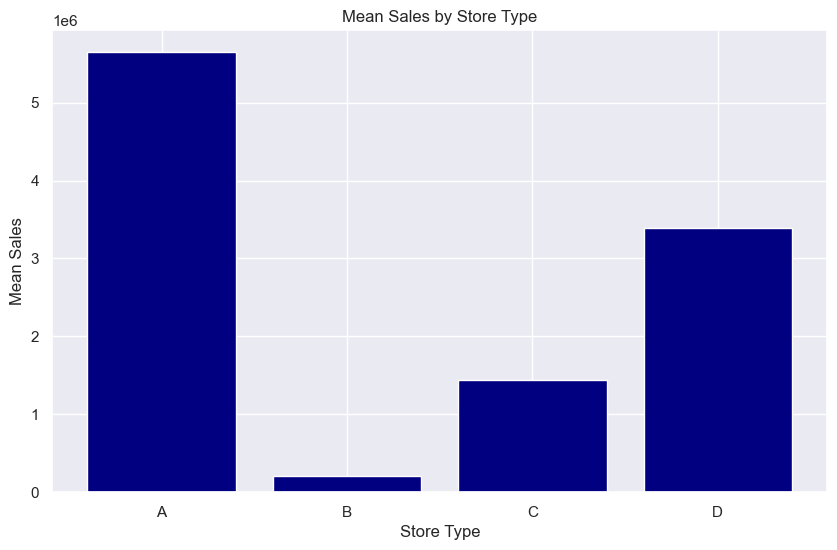

In [55]:
class PlotCreator:
    def __init__(self, data, SeriesX: str, SeriesY: str, color: str = None, xlabel: str = None, ylabel: str = None):
        """
        Initializes the BarPlotCreator with the necessary data and configuration.

        Parameters:
        - data: DataFrame containing the data.
        - SeriesX: The column name to be used for the x-axis.
        - SeriesY: The column name to be used for the y-axis.
        - color: The color of the bars in the plot.
        - xlabel: The label for the x-axis.
        - ylabel: The label for the y-axis.
        """
        self.data = data
        self.SeriesX = SeriesX
        self.SeriesY = SeriesY
        self.color = color
        self.xlabel = xlabel if xlabel else SeriesX
        self.ylabel = ylabel if ylabel else SeriesY
    
    def set_data(self, data):
        """Sets the DataFrame for the plot."""
        self.data = data
    
    def set_series(self, SeriesX: str, SeriesY: str):
        """Sets the series for the x-axis and y-axis."""
        self.SeriesX = SeriesX
        self.SeriesY = SeriesY
    
    def set_labels(self, xlabel: str = None, ylabel: str = None):
        """Sets the labels for the x-axis and y-axis."""
        self.xlabel = xlabel if xlabel else self.SeriesX
        self.ylabel = ylabel if ylabel else self.SeriesY
    
    def set_color(self, color: str):
        """Sets the color of the bars in the plot."""
        self.color = color
    
    def create_bar_plot(self, title: str = 'Bar Plot'):
        """Generates and displays the bar plot."""
        plt.figure(figsize=(10, 6))
        plt.bar(self.data[self.SeriesX], self.data[self.SeriesY], color=self.color)
        plt.title(title)
        plt.xlabel(self.xlabel)
        plt.ylabel(self.ylabel)
        plt.show()
        
    def create_box_plot(self, title: str = 'Sales Distribution by Store Type', figsize=(12, 6)):
        plt.figure(figsize=figsize)
        sns.boxplot(data=self.data, x=self.SeriesX, y=self.SeriesY, color=self.color)
        plt.title(title)
        plt.xlabel(self.xlabel)
        plt.ylabel(self.ylabel)
        plt.show()
    
    
    
store_order =['A', 'B', 'C', 'D']
StoreType_CumilativeSales_with_NO_dummies['StoreType'] = pd.Categorical(StoreType_CumilativeSales_with_NO_dummies['StoreType'], categories=store_order, ordered=True)

bar_plot_creator = PlotCreator(data=sales_by_store_type_with_NO_dummies, SeriesX='StoreType', SeriesY='Mean_Sales', color = 'navy', xlabel='Store Type', ylabel='Mean Sales')
box_plot_creator = PlotCreator(data=StoreType_CumilativeSales_with_NO_dummies, SeriesX='StoreType', SeriesY='Mean_Sales', xlabel='Store Type', ylabel='Mean Sales')
box_plot_creator_forAssortment = PlotCreator(data=StoreType_CumilativeSales_with_NO_dummies, SeriesX='Assortment', SeriesY='Mean_Sales', xlabel='Assortment', ylabel='Mean Sales')

bar_plot_creator.create_bar_plot(title='Mean Sales by Store Type')


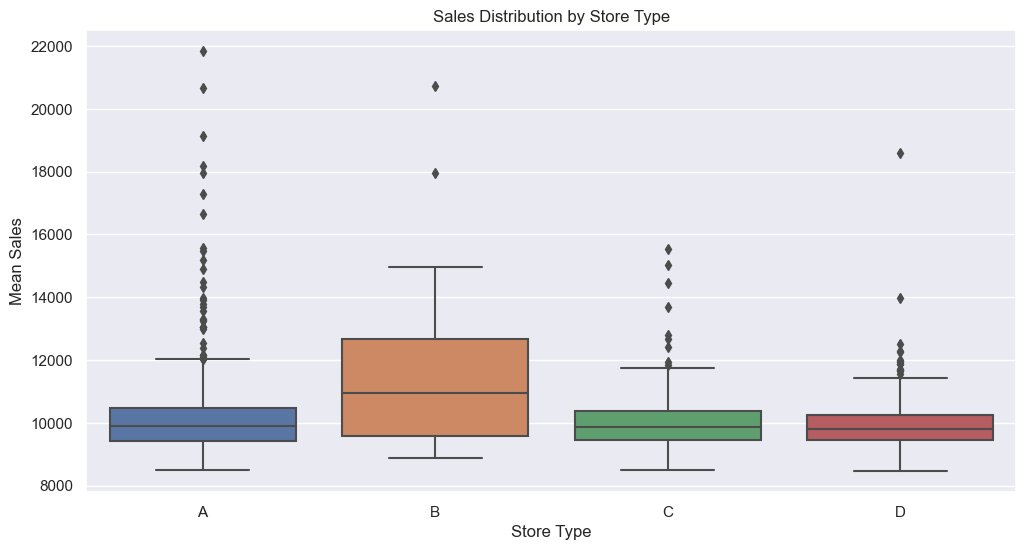

In [56]:

box_plot_creator.create_box_plot(figsize=(12, 6))


Higher variability like in B suggests its harder to make predictions. Moreover, the bar plot shows that StoreType A generates the most sales, suggesting that its outliers are influencing the bar plot statistic



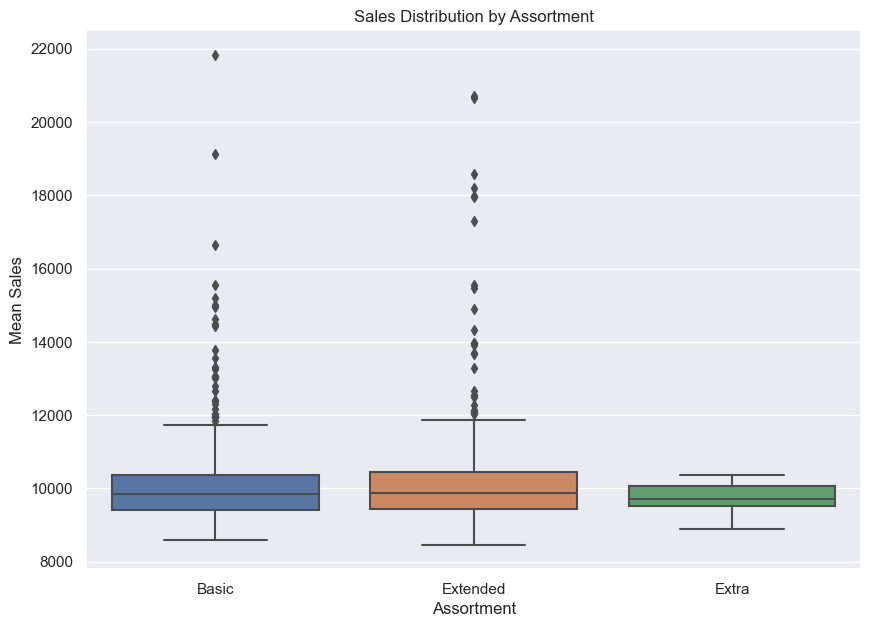

In [57]:
box_plot_creator_forAssortment.create_box_plot(title = 'Sales Distribution by Assortment',figsize=(10, 7))

Basic has the smallest median, suggesting that it is the most likely to sell less

In [58]:
'''
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=StoreType_CumilativeSales, x='StoreType', y='Cumilative_Sum')
plt.title('Sales Distribution by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Sales')
plt.show()
'''

"\nplt.figure(figsize=(12, 6))\n\nplt.subplot(1, 2, 1)\nsns.boxplot(data=StoreType_CumilativeSales, x='StoreType', y='Cumilative_Sum')\nplt.title('Sales Distribution by Store Type')\nplt.xlabel('Store Type')\nplt.ylabel('Sales')\nplt.show()\n"

In [59]:
'''
plt.subplot(1, 2, 2)
sns.boxplot(data=StoreType_CumilativeSales, x='Assortment', y='Cumilative_Sum')
plt.title('Sales Distribution by Assortment')
plt.xlabel('Store Type')
plt.ylabel('Sales')
plt.show()
'''

"\nplt.subplot(1, 2, 2)\nsns.boxplot(data=StoreType_CumilativeSales, x='Assortment', y='Cumilative_Sum')\nplt.title('Sales Distribution by Assortment')\nplt.xlabel('Store Type')\nplt.ylabel('Sales')\nplt.show()\n"

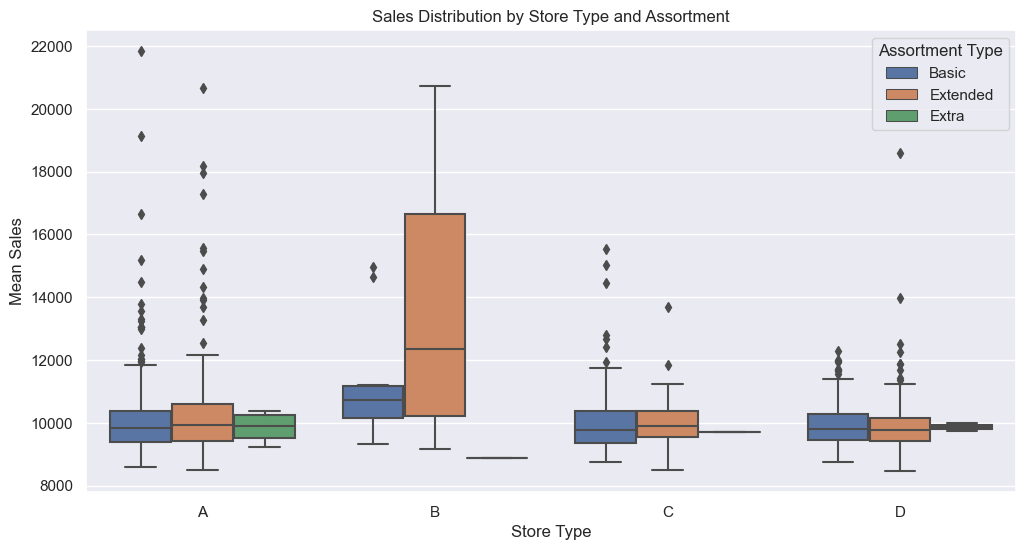

In [60]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=StoreType_CumilativeSales_with_NO_dummies, x='StoreType', y='Mean_Sales', hue='Assortment')
plt.title('Sales Distribution by Store Type and Assortment')
plt.xlabel('Store Type')
plt.ylabel('Mean Sales')
plt.legend(title='Assortment Type', loc='upper right')
plt.show()

Storetype A sells all types of products. Storetype B sells 0 and 2. Storetypes 2 and 3 are making barely and sales of 1 and should consider liquidating all their inventory of the product 1 and discontinuing the product as their product may not be neccessary for their target custumers, focusing on increasing sales of the other 2 products.
-does not suggest that more products results in a higher number of sales
Improvement: Check for seasonality in inventory

In [61]:
StoreType_CumilativeSales

,Store,Cumulative_Sales,Mean_Sales,StoreType,Assortment,Promo2,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Normalised_Sales_cumulative,Normalised_Sales_Mean
0,1,18859.0,9429.500000,2,0,0,1270.0,9.0,2008.0,NaN,NaN,NaN,0.006965,7.172106
1,2,170173.0,9454.055556,0,0,1,570.0,11.0,2007.0,13.0,2010.0,"Jan,Apr,Jul,Oct",0.062845,7.190783
2,3,1927200.0,9883.076923,0,0,1,14130.0,12.0,2006.0,14.0,2011.0,"Jan,Apr,Jul,Oct",0.711714,7.517098
3,4,5870093.0,10463.623886,2,2,0,620.0,9.0,2009.0,NaN,NaN,NaN,2.167822,7.958663
4,5,150450.0,9403.125000,0,0,0,29910.0,4.0,2015.0,NaN,NaN,NaN,0.055561,7.152045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048,1111,375489.0,9387.225000,0,0,1,1900.0,6.0,2014.0,31.0,2013.0,"Jan,Apr,Jul,Oct",0.138668,7.139951
1049,1112,5973167.0,11851.521825,2,2,0,1880.0,4.0,2006.0,NaN,NaN,NaN,2.205887,9.014303
1050,1113,755444.0,9810.961039,0,0,0,9260.0,NaN,NaN,NaN,NaN,NaN,0.278985,7.462246
1051,1114,16202585.0,20666.562500,0,2,0,870.0,NaN,NaN,NaN,NaN,NaN,5.983606,15.719049


In [62]:
Normalised_df

,Store,Cumulative_Sales,Mean_Sales,StoreType,Assortment,Promo2,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Normalised_Sales_cumulative,Normalised_Sales_Mean
0,1,18859.0,9429.500000,2,0,0,1270.0,9.0,2008.0,NaN,NaN,NaN,0.006965,7.172106
1,2,170173.0,9454.055556,0,0,1,570.0,11.0,2007.0,13.0,2010.0,"Jan,Apr,Jul,Oct",0.062845,7.190783
2,3,1927200.0,9883.076923,0,0,1,14130.0,12.0,2006.0,14.0,2011.0,"Jan,Apr,Jul,Oct",0.711714,7.517098
3,4,5870093.0,10463.623886,2,2,0,620.0,9.0,2009.0,NaN,NaN,NaN,2.167822,7.958663
4,5,150450.0,9403.125000,0,0,0,29910.0,4.0,2015.0,NaN,NaN,NaN,0.055561,7.152045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1110,1111,375489.0,9387.225000,0,0,1,1900.0,6.0,2014.0,31.0,2013.0,"Jan,Apr,Jul,Oct",0.138668,7.139951
1111,1112,5973167.0,11851.521825,2,2,0,1880.0,4.0,2006.0,NaN,NaN,NaN,2.205887,9.014303
1112,1113,755444.0,9810.961039,0,2,0,9260.0,NaN,NaN,NaN,NaN,NaN,0.278985,7.462246
1113,1114,16202585.0,20666.562500,0,2,0,870.0,NaN,NaN,NaN,NaN,NaN,5.983606,15.719049


## Cumilative Sales vs Store Type  ##

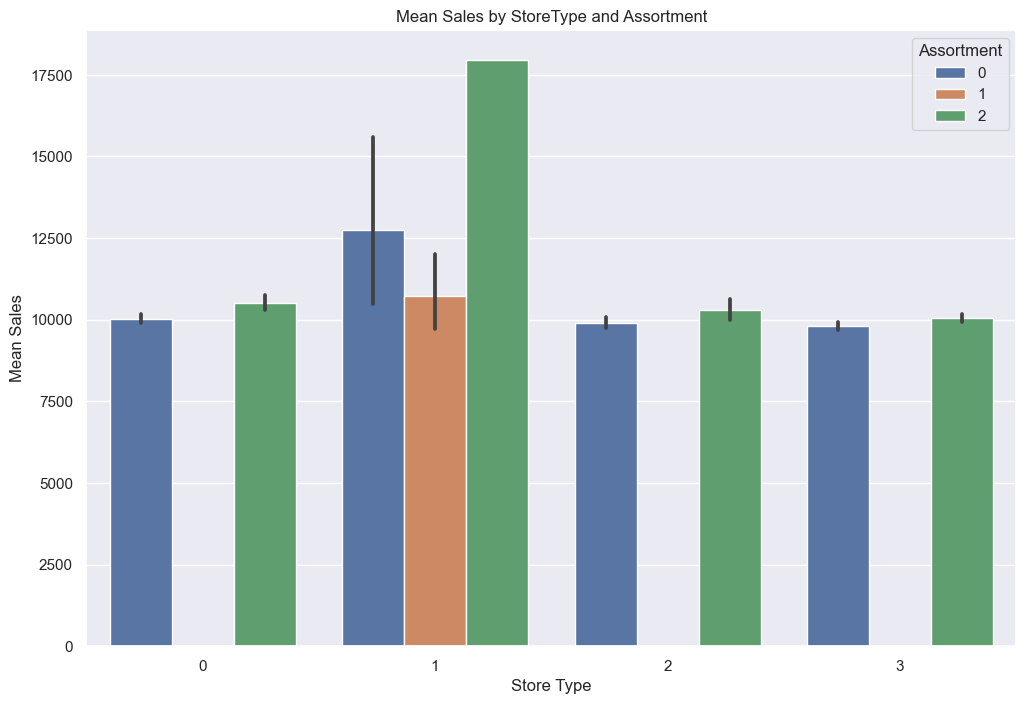

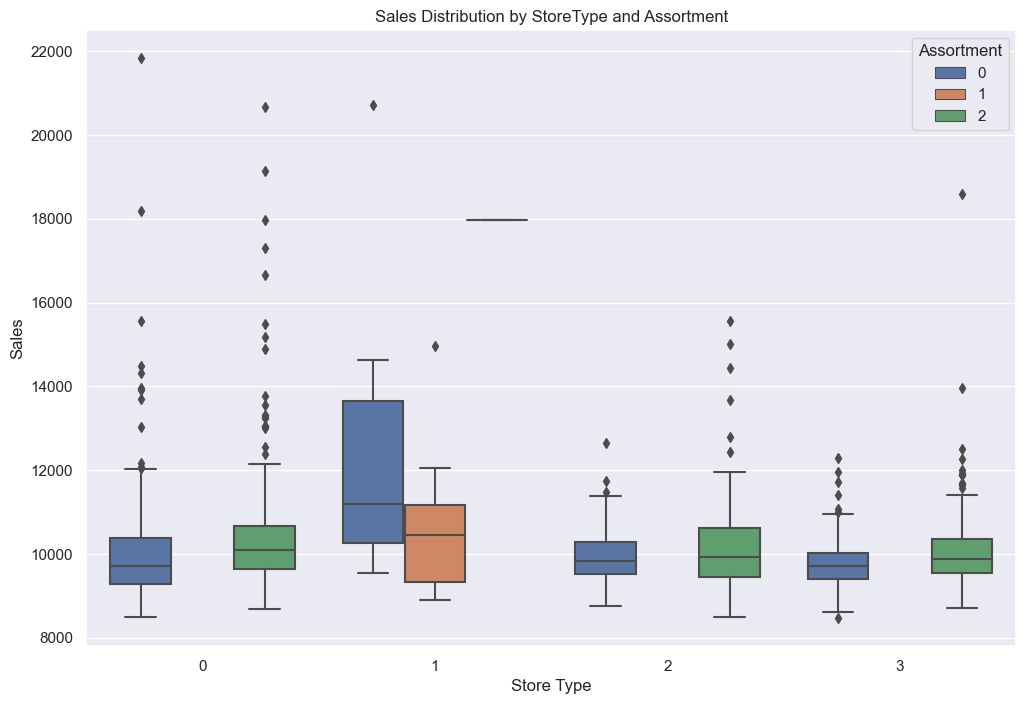

In [63]:

import seaborn as sns

# Bar chart for cumulative sales by StoreType and Assortment
plt.figure(figsize=(12, 8))
sns.barplot(x='StoreType', y='Mean_Sales', hue='Assortment', data=Normalised_df)
plt.title('Mean Sales by StoreType and Assortment')
plt.xlabel('Store Type')
plt.ylabel('Mean Sales')
plt.show()

# Box plot for sales distribution by StoreType and Assortment
plt.figure(figsize=(12, 8))
sns.boxplot(x='StoreType', y='Mean_Sales', hue='Assortment', data=Normalised_df)
plt.title('Sales Distribution by StoreType and Assortment')
plt.xlabel('Store Type')
plt.ylabel('Sales')
plt.show()



In [64]:
cumulative_sales_by_type_assortment = StoreType_CumilativeSales.groupby(
    ['StoreType', 'Assortment']
)['Mean_Sales'].mean().reset_index()

In [65]:
cumulative_sales_by_type_assortment

,StoreType,Assortment,Mean_Sales
0,0,0,10155.608895
1,0,1,9863.521515
2,0,2,10290.155775
3,1,0,11275.055050
4,1,1,8891.428571
5,1,2,13693.090876
6,2,0,10152.896945
7,2,1,9711.755814
8,2,2,10040.485573
9,3,0,9958.407191


## Correlation Matrix ##

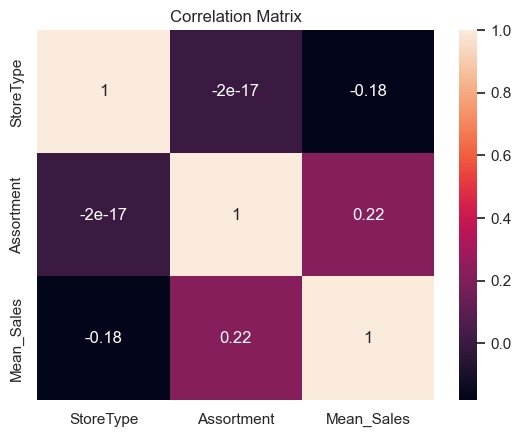

In [66]:
correlation_matrix = cumulative_sales_by_type_assortment.corr()
sns.heatmap(correlation_matrix, annot=True)
plt.title('Correlation Matrix')
plt.show()

## K-Means shit ##

C:\Users\aryak\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\aryak\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


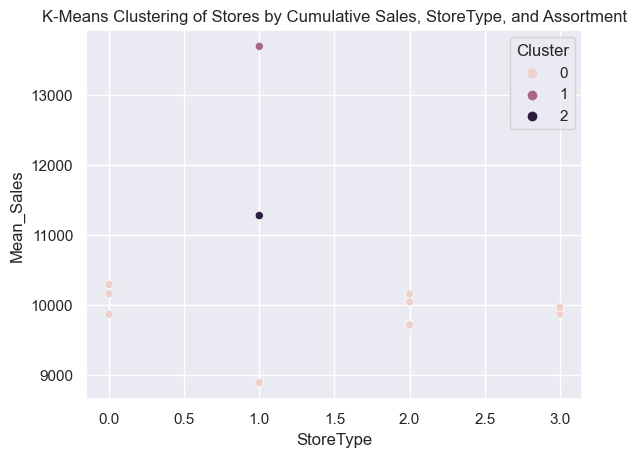

In [67]:

# Assuming you want to cluster based on StoreType and Assortment
clustering_data = pd.get_dummies(cumulative_sales_by_type_assortment[['Mean_Sales', 'StoreType', 'Assortment']])
kmeans = KMeans(n_clusters=3)
kmeans.fit(clustering_data)
cumulative_sales_by_type_assortment['Cluster'] = kmeans.labels_

sns.scatterplot(x='StoreType', y='Mean_Sales', hue='Cluster', data=cumulative_sales_by_type_assortment)
plt.title('K-Means Clustering of Stores by Cumulative Sales, StoreType, and Assortment')
plt.show()

In [68]:
SalesSum_And_Store_copy

,Store,Cumulative_Sales,Mean_Sales,StoreType,Assortment,Promo2,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,18859.0,9429.500000,2,0,0,1270.0,9.0,2008.0,NaN,NaN,NaN
1,2,170173.0,9454.055556,0,0,1,570.0,11.0,2007.0,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,1927200.0,9883.076923,0,0,1,14130.0,12.0,2006.0,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5870093.0,10463.623886,2,2,0,620.0,9.0,2009.0,NaN,NaN,NaN
4,5,150450.0,9403.125000,0,0,0,29910.0,4.0,2015.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1110,1111,375489.0,9387.225000,0,0,1,1900.0,6.0,2014.0,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,5973167.0,11851.521825,2,2,0,1880.0,4.0,2006.0,NaN,NaN,NaN
1112,1113,755444.0,9810.961039,0,2,0,9260.0,NaN,NaN,NaN,NaN,NaN
1113,1114,16202585.0,20666.562500,0,2,0,870.0,NaN,NaN,NaN,NaN,NaN


In [69]:
SalesSum_And_Store_copy

,Store,Cumulative_Sales,Mean_Sales,StoreType,Assortment,Promo2,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,18859.0,9429.500000,2,0,0,1270.0,9.0,2008.0,NaN,NaN,NaN
1,2,170173.0,9454.055556,0,0,1,570.0,11.0,2007.0,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,1927200.0,9883.076923,0,0,1,14130.0,12.0,2006.0,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5870093.0,10463.623886,2,2,0,620.0,9.0,2009.0,NaN,NaN,NaN
4,5,150450.0,9403.125000,0,0,0,29910.0,4.0,2015.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1110,1111,375489.0,9387.225000,0,0,1,1900.0,6.0,2014.0,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,5973167.0,11851.521825,2,2,0,1880.0,4.0,2006.0,NaN,NaN,NaN
1112,1113,755444.0,9810.961039,0,2,0,9260.0,NaN,NaN,NaN,NaN,NaN
1113,1114,16202585.0,20666.562500,0,2,0,870.0,NaN,NaN,NaN,NaN,NaN


do cliative_sum versus customers 

In [70]:
SalesSum_And_Store_copy_1 = SalesSum_And_Store_copy.copy()
SalesSum_And_Store_copy_1['Customers'] = grouped_df['Customers'].mean()
SalesSum_And_Store_copy_1.isna().sum()

Store                          0
Cumulative_Sales               0
Mean_Sales                     0
StoreType                      0
Assortment                     0
Promo2                         0
CompetitionDistance            3
CompetitionOpenSinceMonth    340
CompetitionOpenSinceYear     340
Promo2SinceWeek              510
Promo2SinceYear              510
PromoInterval                510
Customers                     61
dtype: int64

In [71]:
SalesSum_And_Store_copy_1

,Store,Cumulative_Sales,Mean_Sales,StoreType,Assortment,Promo2,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Customers
0,1,18859.0,9429.500000,2,0,0,1270.0,9.0,2008.0,NaN,NaN,NaN,NaN
1,2,170173.0,9454.055556,0,0,1,570.0,11.0,2007.0,13.0,2010.0,"Jan,Apr,Jul,Oct",1105.000000
2,3,1927200.0,9883.076923,0,0,1,14130.0,12.0,2006.0,14.0,2011.0,"Jan,Apr,Jul,Oct",888.000000
3,4,5870093.0,10463.623886,2,2,0,620.0,9.0,2009.0,NaN,NaN,NaN,952.076923
4,5,150450.0,9403.125000,0,0,0,29910.0,4.0,2015.0,NaN,NaN,NaN,1404.376114
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1110,1111,375489.0,9387.225000,0,0,1,1900.0,6.0,2014.0,31.0,2013.0,"Jan,Apr,Jul,Oct",861.166667
1111,1112,5973167.0,11851.521825,2,2,0,1880.0,4.0,2006.0,NaN,NaN,NaN,698.050000
1112,1113,755444.0,9810.961039,0,2,0,9260.0,NaN,NaN,NaN,NaN,NaN,931.575397
1113,1114,16202585.0,20666.562500,0,2,0,870.0,NaN,NaN,NaN,NaN,NaN,957.792208


In [72]:
SalesSum_And_Store_copy_1= Rossman_train_df.groupby('Store')['Customers'].mean().reset_index()
SalesSum_And_Store_copy_1
merged_df_including_customers = Normalised_df.merge(SalesSum_And_Store_copy_1[['Store', 'Customers']], on='Store', how='left')
merged_df_including_customers

,Store,Cumulative_Sales,Mean_Sales,StoreType,Assortment,Promo2,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Normalised_Sales_cumulative,Normalised_Sales_Mean,Customers
0,1,18859.0,9429.500000,2,0,0,1270.0,9.0,2008.0,NaN,NaN,NaN,0.006965,7.172106,1105.000000
1,2,170173.0,9454.055556,0,0,1,570.0,11.0,2007.0,13.0,2010.0,"Jan,Apr,Jul,Oct",0.062845,7.190783,888.000000
2,3,1927200.0,9883.076923,0,0,1,14130.0,12.0,2006.0,14.0,2011.0,"Jan,Apr,Jul,Oct",0.711714,7.517098,952.076923
3,4,5870093.0,10463.623886,2,2,0,620.0,9.0,2009.0,NaN,NaN,NaN,2.167822,7.958663,1404.376114
4,5,150450.0,9403.125000,0,0,0,29910.0,4.0,2015.0,NaN,NaN,NaN,0.055561,7.152045,859.250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048,1111,375489.0,9387.225000,0,0,1,1900.0,6.0,2014.0,31.0,2013.0,"Jan,Apr,Jul,Oct",0.138668,7.139951,698.050000
1049,1112,5973167.0,11851.521825,2,2,0,1880.0,4.0,2006.0,NaN,NaN,NaN,2.205887,9.014303,931.575397
1050,1113,755444.0,9810.961039,0,2,0,9260.0,NaN,NaN,NaN,NaN,NaN,0.278985,7.462246,957.792208
1051,1114,16202585.0,20666.562500,0,2,0,870.0,NaN,NaN,NaN,NaN,NaN,5.983606,15.719049,3200.946429


In [73]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for month in months:
    merged_df_including_customers[f'Promo_{month}'] = merged_df_including_customers['PromoInterval'].apply(lambda x: 1 if month in str(x) else 0)
merged_df_including_customers.drop(columns=['PromoInterval'], inplace=True)
imputer = SimpleImputer(strategy='mean')
merged_df_including_customers[['CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear',
            'Promo2SinceWeek', 'Promo2SinceYear']] = imputer.fit_transform(
    merged_df_including_customers[['CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear',
                'Promo2SinceWeek', 'Promo2SinceYear']])

scaler = StandardScaler()
merged_df_including_customers[['CompetitionDistance']] = scaler.fit_transform(merged_df_including_customers[['CompetitionDistance']])

In [74]:
SalesSum_And_Store_copy_1 = SalesSum_And_Store_copy_1.dropna(axis = 'index', how = 'any', subset = ['Customers'])
#merged_df_including_customers = merged_df_including_customers.dropna(axis = 'index', how = 'any', subset = ['Mean_Sales'])

In [75]:
SalesSum_And_Store_copy_1.reset_index(inplace = True)
SalesSum_And_Store_copy_1

,index,Store,Customers
0,0,1,1105.000000
1,1,2,888.000000
2,2,3,952.076923
3,3,4,1404.376114
4,4,5,859.250000
...,...,...,...
1048,1048,1111,698.050000
1049,1049,1112,931.575397
1050,1050,1113,957.792208
1051,1051,1114,3200.946429


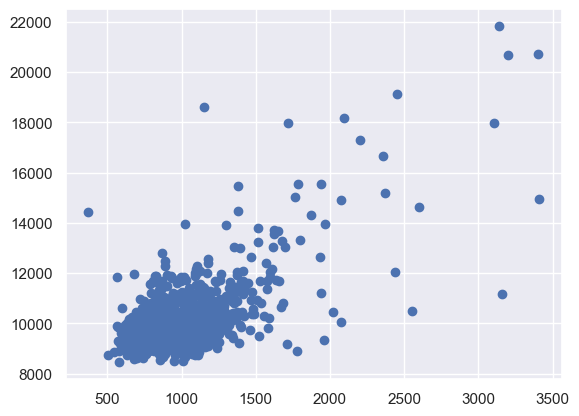

In [76]:
plt.scatter(merged_df_including_customers['Customers'], merged_df_including_customers['Mean_Sales'])

In [77]:
merged_df_including_customers[['Mean_Sales', 'Customers', 'Assortment']].isnull().sum()

Mean_Sales    0
Customers     0
Assortment    0
dtype: int64

In [78]:
clustering_data_Customers = pd.get_dummies(merged_df_including_customers[['Mean_Sales', 'Customers', 'Assortment']])
clustering_data_Customers

,Mean_Sales,Customers,Assortment
0,9429.500000,1105.000000,0
1,9454.055556,888.000000,0
2,9883.076923,952.076923,0
3,10463.623886,1404.376114,2
4,9403.125000,859.250000,0
...,...,...,...
1048,9387.225000,698.050000,0
1049,11851.521825,931.575397,2
1050,9810.961039,957.792208,2
1051,20666.562500,3200.946429,2


C:\Users\aryak\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\aryak\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


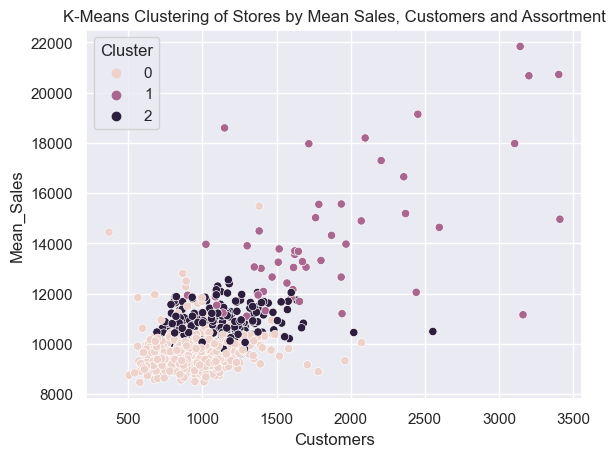

In [79]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(merged_df_including_customers)
merged_df_including_customers['Cluster'] = kmeans.labels_

sns.scatterplot(x='Customers', y='Mean_Sales', hue='Cluster', data=merged_df_including_customers)
plt.title('K-Means Clustering of Stores by Mean Sales, Customers and Assortment')
plt.show()

C:\Users\aryak\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\aryak\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


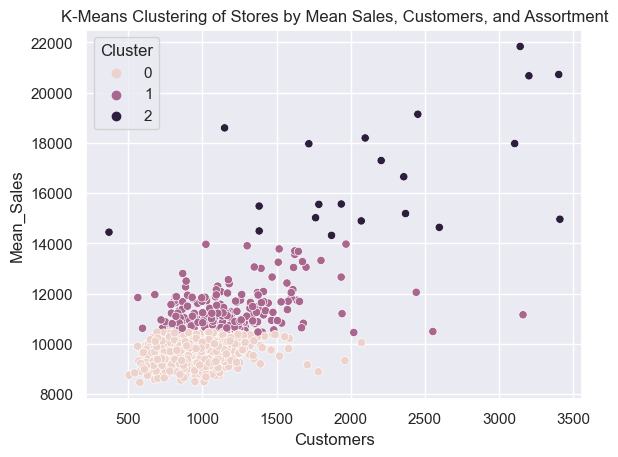

In [80]:
clustering_data_Customers = pd.get_dummies(merged_df_including_customers[['Mean_Sales', 'Customers', 'StoreType']])
kmeans = KMeans(n_clusters=3)
kmeans.fit(clustering_data_Customers)
merged_df_including_customers['Cluster'] = kmeans.labels_

sns.scatterplot(x='Customers', y='Mean_Sales', hue='Cluster', data=merged_df_including_customers)
plt.title('K-Means Clustering of Stores by Mean Sales, Customers, and Assortment')
plt.show()

In [81]:
merged_df_including_customers

,Store,Cumulative_Sales,Mean_Sales,StoreType,Assortment,Promo2,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2SinceWeek,...,Promo_Apr,Promo_May,Promo_Jun,Promo_Jul,Promo_Aug,Promo_Sep,Promo_Oct,Promo_Nov,Promo_Dec,Cluster
0,1,18859.0,9429.500000,2,0,0,-0.552831,9.000000,2008.000000,23.511971,...,0,0,0,0,0,0,0,0,0,0
1,2,170173.0,9454.055556,0,0,1,-0.642876,11.000000,2007.000000,13.000000,...,1,0,0,1,0,0,1,0,0,0
2,3,1927200.0,9883.076923,0,0,1,1.101442,12.000000,2006.000000,14.000000,...,1,0,0,1,0,0,1,0,0,0
3,4,5870093.0,10463.623886,2,2,0,-0.636445,9.000000,2009.000000,23.511971,...,0,0,0,0,0,0,0,0,0,1
4,5,150450.0,9403.125000,0,0,0,3.131334,4.000000,2015.000000,23.511971,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048,1111,375489.0,9387.225000,0,0,1,-0.471789,6.000000,2014.000000,31.000000,...,1,0,0,1,0,0,1,0,0,0
1049,1112,5973167.0,11851.521825,2,2,0,-0.474362,4.000000,2006.000000,23.511971,...,0,0,0,0,0,0,0,0,0,1
1050,1113,755444.0,9810.961039,0,2,0,0.474979,7.204769,2008.681627,23.511971,...,0,0,0,0,0,0,0,0,0,0
1051,1114,16202585.0,20666.562500,0,2,0,-0.604285,7.204769,2008.681627,23.511971,...,0,0,0,0,0,0,0,0,0,2


## Linear analysis ##

In [82]:
merged_df_including_customers_numpy = merged_df_including_customers.to_numpy()
if isinstance(merged_df_including_customers_numpy,np.ndarray):
    X = merged_df_including_customers_numpy[:,5].reshape(-1,1)
    Y = merged_df_including_customers_numpy[:,1]
    model = LinearRegression()
    model.fit(X, Y)

intercept = model.intercept_
intercept
slope = model.coef_[0]
slope


-1040463.9174412322

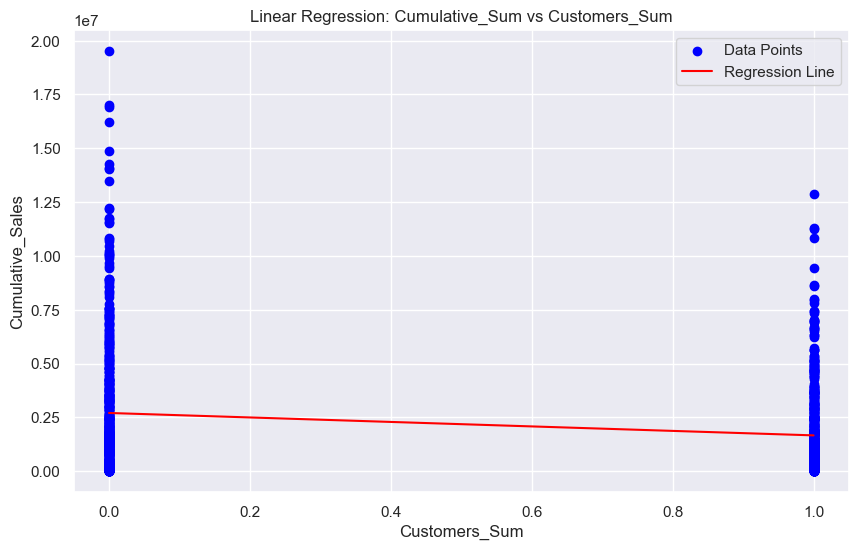

0.036909424642316835

In [83]:
y_pred = model.predict(X)


plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color='blue', label='Data Points')
plt.plot(X, y_pred, color='red', label='Regression Line')
plt.title('Linear Regression: Cumulative_Sum vs Customers_Sum')
plt.xlabel('Customers_Sum')
plt.ylabel('Cumulative_Sales')
plt.legend()
plt.show()

# Optional: Print R-squared value
r_squared = model.score(X, Y)
r_squared 

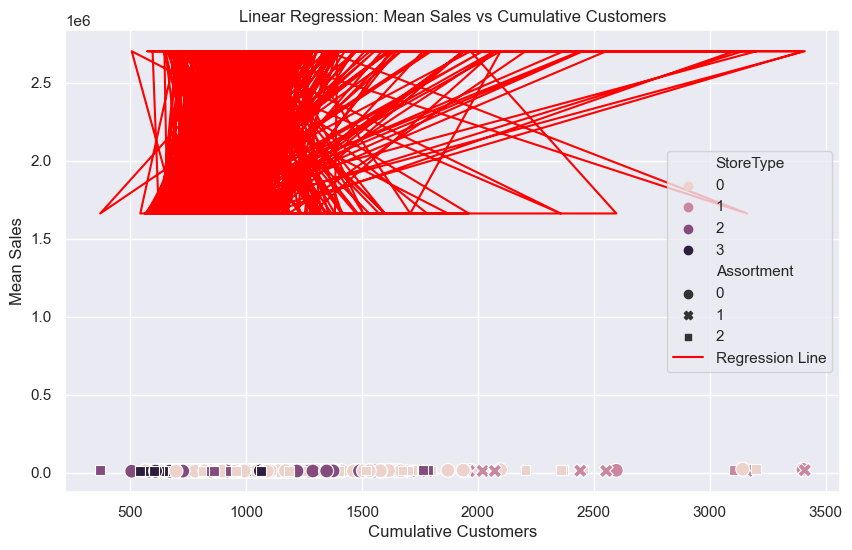

                            OLS Regression Results                            
Dep. Variable:             Mean_Sales   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     18.05
Date:                Thu, 17 Oct 2024   Prob (F-statistic):           2.34e-05
Time:                        23:50:42   Log-Likelihood:                -9046.7
No. Observations:                1053   AIC:                         1.810e+04
Df Residuals:                    1051   BIC:                         1.811e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.032e+04     57.752    178.729      0.0

In [84]:
# Prepare the input (X) and output (y)
#X = merged_df_including_customers['Customers'].values.reshape(-1, 1)





# Plot the data and the regression line
plt.figure(figsize=(10, 6))

# Use seaborn to scatter plot the data, color by StoreType
sns.scatterplot(x='Customers', y='Mean_Sales', hue='StoreType', style='Assortment', data=merged_df_including_customers, s=100)

# Plot the regression line
plt.plot(merged_df_including_customers['Customers'], y_pred, color='red', label='Regression Line')

# Add titles and labels
plt.title('Linear Regression: Mean Sales vs Cumulative Customers')
plt.xlabel('Cumulative Customers')
plt.ylabel('Mean Sales')
plt.legend()
plt.show()

x = sm.add_constant(X)
y = merged_df_including_customers['Mean_Sales']

# Fit the OLS model
model = sm.OLS(y, x)
results = model.fit()
print(results.summary())

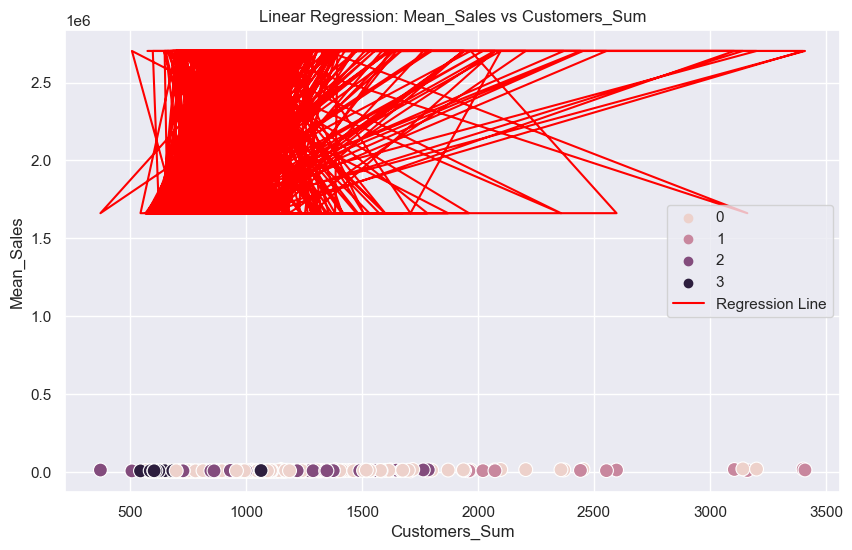

In [85]:
plt.figure(figsize=(10, 6))

# Use seaborn to scatter plot the data, color by StoreType
sns.scatterplot(x='Customers', y='Mean_Sales', hue='StoreType', data=merged_df_including_customers, s=100)

# Plot the regression line
plt.plot(merged_df_including_customers['Customers'], y_pred, color='red', label='Regression Line')

# Add titles and labels
plt.title('Linear Regression: Mean_Sales vs Customers_Sum')
plt.xlabel('Customers_Sum')
plt.ylabel('Mean_Sales')
plt.legend()
plt.show()

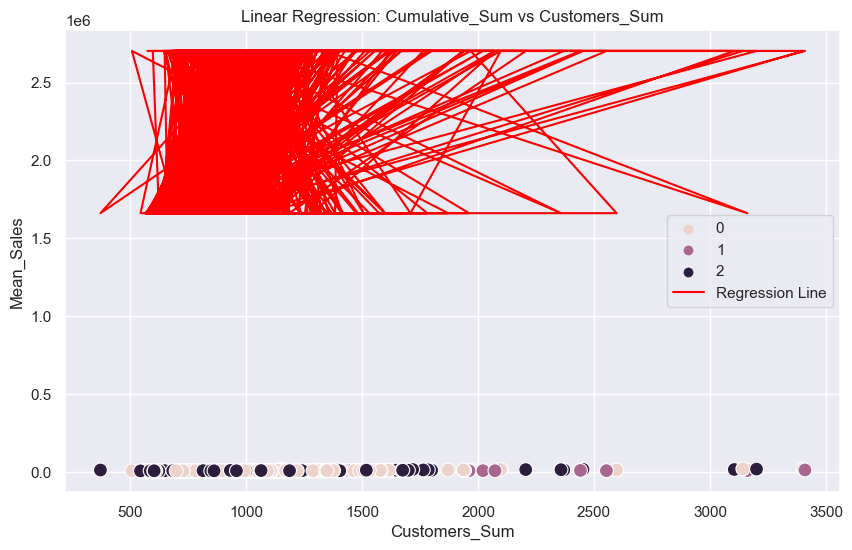

In [86]:
plt.figure(figsize=(10, 6))

# Use seaborn to scatter plot the data, color by StoreType
sns.scatterplot(x='Customers', y='Mean_Sales', hue='Assortment', data=merged_df_including_customers, s=100)

# Plot the regression line
plt.plot(merged_df_including_customers['Customers'], y_pred, color='red', label='Regression Line')

# Add titles and labels
plt.title('Linear Regression: Cumulative_Sum vs Customers_Sum')
plt.xlabel('Customers_Sum')
plt.ylabel('Mean_Sales')
plt.legend()
plt.show()

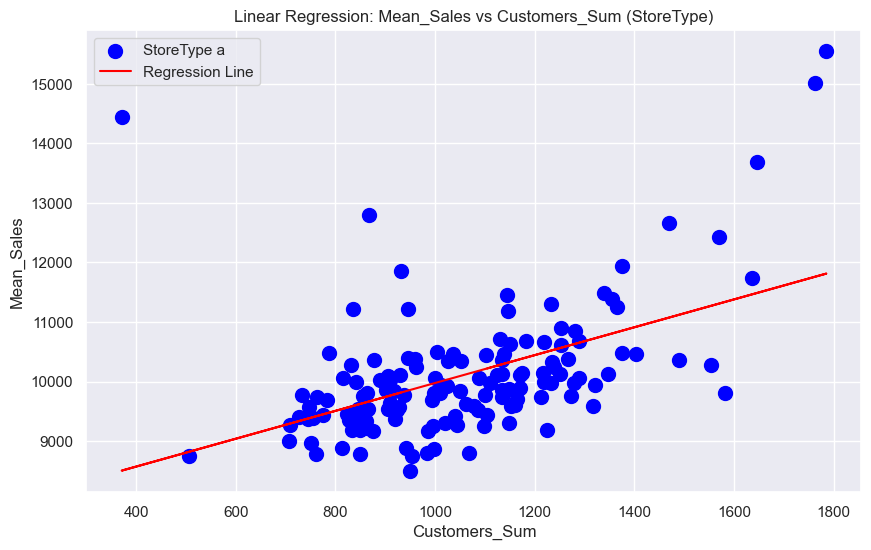

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.253
Model:                            OLS   Adj. R-squared:                  0.247
Method:                 Least Squares   F-statistic:                     47.63
Date:                Thu, 17 Oct 2024   Prob (F-statistic):           1.61e-10
Time:                        23:50:44   Log-Likelihood:                -1183.5
No. Observations:                 143   AIC:                             2371.
Df Residuals:                     141   BIC:                             2377.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       7635.2442    366.036     20.859      0.0

In [87]:
def plot_storetype(storetype_value: int = 0):
    filtered_df = merged_df_including_customers[merged_df_including_customers['StoreType'] == storetype_value]

    # Prepare the input (X) and output (y) for the filtered data
    X_filtered = filtered_df['Customers'].values.reshape(-1, 1)
    y_filtered = filtered_df['Mean_Sales'].values

    # Create and fit the linear regression model
    model_filtered = LinearRegression()
    model_filtered.fit(X_filtered, y_filtered)

    # Predict y values for the regression line for filtered data
    y_pred_filtered = model_filtered.predict(X_filtered)

    # Plot the filtered data (StoreType 'a') and the regression line
    plt.figure(figsize=(10, 6))

    # Scatter plot for StoreType 'a'
    plt.scatter(filtered_df['Customers'], filtered_df['Mean_Sales'], color='blue', label='StoreType a', s=100)

    # Plot the regression line for StoreType 'a'
    plt.plot(filtered_df['Customers'], y_pred_filtered, color='red', label='Regression Line')

    # Add titles and labels
    plt.title('Linear Regression: Mean_Sales vs Customers_Sum (StoreType)')
    plt.xlabel('Customers_Sum')
    plt.ylabel('Mean_Sales')
    plt.legend()
    plt.show()
    
    x = sm.add_constant(X_filtered)
    #y = merged_df_including_customers['Cumilative_Sum']

# Fit the OLS model
    model = sm.OLS(y_filtered, x)
    results = model.fit()
    print(results.summary())
plot_storetype(2)

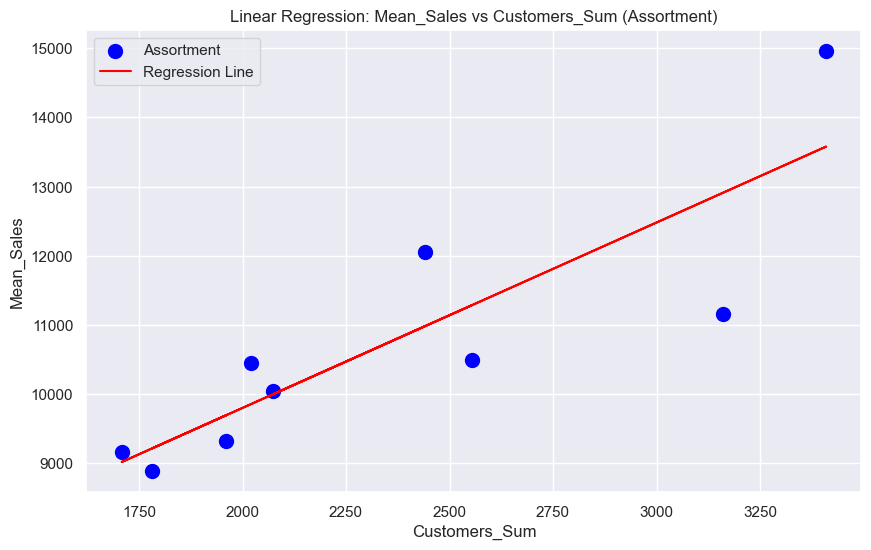

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.739
Model:                            OLS   Adj. R-squared:                  0.701
Method:                 Least Squares   F-statistic:                     19.77
Date:                Thu, 17 Oct 2024   Prob (F-statistic):            0.00298
Time:                        23:50:45   Log-Likelihood:                -74.043
No. Observations:                   9   AIC:                             152.1
Df Residuals:                       7   BIC:                             152.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4445.5932   1453.733      3.058      0.0

C:\Users\aryak\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=9
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [88]:
def plot_assortment(assortment: int = 0):
    filtered_df = merged_df_including_customers[merged_df_including_customers['Assortment'] == assortment]

    # Prepare the input (X) and output (y) for the filtered data
    X_filtered = filtered_df['Customers'].values.reshape(-1, 1)
    y_filtered = filtered_df['Mean_Sales'].values

    # Create and fit the linear regression model
    model_filtered = LinearRegression()
    model_filtered.fit(X_filtered, y_filtered)

    # Predict y values for the regression line for filtered data
    y_pred_filtered = model_filtered.predict(X_filtered)

    # Plot the filtered data (StoreType 'a') and the regression line
    plt.figure(figsize=(10, 6))

    # Scatter plot for StoreType 'a'
    plt.scatter(filtered_df['Customers'], filtered_df['Mean_Sales'], color='blue', label='Assortment', s=100)

    # Plot the regression line for StoreType 'a'
    plt.plot(filtered_df['Customers'], y_pred_filtered, color='red', label='Regression Line')

    # Add titles and labels
    plt.title('Linear Regression: Mean_Sales vs Customers_Sum (Assortment)')
    plt.xlabel('Customers_Sum')
    plt.ylabel('Mean_Sales')
    plt.legend()
    plt.show()
    
    x = sm.add_constant(X_filtered)
    #y = merged_df_including_customers['Cumilative_Sum']

# Fit the OLS model
    model = sm.OLS(y_filtered, x)
    results = model.fit()
    print(results.summary())
plot_assortment(1)

In [89]:
merged_df_including_customers

,Store,Cumulative_Sales,Mean_Sales,StoreType,Assortment,Promo2,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2SinceWeek,...,Promo_Apr,Promo_May,Promo_Jun,Promo_Jul,Promo_Aug,Promo_Sep,Promo_Oct,Promo_Nov,Promo_Dec,Cluster
0,1,18859.0,9429.500000,2,0,0,-0.552831,9.000000,2008.000000,23.511971,...,0,0,0,0,0,0,0,0,0,0
1,2,170173.0,9454.055556,0,0,1,-0.642876,11.000000,2007.000000,13.000000,...,1,0,0,1,0,0,1,0,0,0
2,3,1927200.0,9883.076923,0,0,1,1.101442,12.000000,2006.000000,14.000000,...,1,0,0,1,0,0,1,0,0,0
3,4,5870093.0,10463.623886,2,2,0,-0.636445,9.000000,2009.000000,23.511971,...,0,0,0,0,0,0,0,0,0,1
4,5,150450.0,9403.125000,0,0,0,3.131334,4.000000,2015.000000,23.511971,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048,1111,375489.0,9387.225000,0,0,1,-0.471789,6.000000,2014.000000,31.000000,...,1,0,0,1,0,0,1,0,0,0
1049,1112,5973167.0,11851.521825,2,2,0,-0.474362,4.000000,2006.000000,23.511971,...,0,0,0,0,0,0,0,0,0,1
1050,1113,755444.0,9810.961039,0,2,0,0.474979,7.204769,2008.681627,23.511971,...,0,0,0,0,0,0,0,0,0,0
1051,1114,16202585.0,20666.562500,0,2,0,-0.604285,7.204769,2008.681627,23.511971,...,0,0,0,0,0,0,0,0,0,2


## Train-Test split ## 

In [90]:
X = merged_df_including_customers[['Customers']]
y = merged_df_including_customers['Normalised_Sales_Mean'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Initialize the linear regression model
model = LinearRegression()

# Fit the model on the training data
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluate the model performance
mse = mean_squared_error(y_test, y_pred)
print(mse)
RMSE = np.sqrt(mse)
RMSE

0.4733184262291687


0.6879814141596913

In [91]:
merged_df_including_customers['StoreType'].unique()

array([2, 0, 3, 1], dtype=int64)

In [92]:
merged_df_including_customers

,Store,Cumulative_Sales,Mean_Sales,StoreType,Assortment,Promo2,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2SinceWeek,...,Promo_Apr,Promo_May,Promo_Jun,Promo_Jul,Promo_Aug,Promo_Sep,Promo_Oct,Promo_Nov,Promo_Dec,Cluster
0,1,18859.0,9429.500000,2,0,0,-0.552831,9.000000,2008.000000,23.511971,...,0,0,0,0,0,0,0,0,0,0
1,2,170173.0,9454.055556,0,0,1,-0.642876,11.000000,2007.000000,13.000000,...,1,0,0,1,0,0,1,0,0,0
2,3,1927200.0,9883.076923,0,0,1,1.101442,12.000000,2006.000000,14.000000,...,1,0,0,1,0,0,1,0,0,0
3,4,5870093.0,10463.623886,2,2,0,-0.636445,9.000000,2009.000000,23.511971,...,0,0,0,0,0,0,0,0,0,1
4,5,150450.0,9403.125000,0,0,0,3.131334,4.000000,2015.000000,23.511971,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048,1111,375489.0,9387.225000,0,0,1,-0.471789,6.000000,2014.000000,31.000000,...,1,0,0,1,0,0,1,0,0,0
1049,1112,5973167.0,11851.521825,2,2,0,-0.474362,4.000000,2006.000000,23.511971,...,0,0,0,0,0,0,0,0,0,1
1050,1113,755444.0,9810.961039,0,2,0,0.474979,7.204769,2008.681627,23.511971,...,0,0,0,0,0,0,0,0,0,0
1051,1114,16202585.0,20666.562500,0,2,0,-0.604285,7.204769,2008.681627,23.511971,...,0,0,0,0,0,0,0,0,0,2


## Random Forest ##

In [93]:
df_encoded = pd.get_dummies(merged_df_including_customers, columns=['StoreType'])
df_encoded.rename(columns = {'StoreType_0': 'StoreType_A', 'StoreType_1': 'StoreType_B', 'StoreType_2': 'StoreType_C', 'StoreType_3': 'StoreType_D'}, inplace = True)
df_encoded

,Store,Cumulative_Sales,Mean_Sales,Assortment,Promo2,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2SinceWeek,Promo2SinceYear,...,Promo_Aug,Promo_Sep,Promo_Oct,Promo_Nov,Promo_Dec,Cluster,StoreType_A,StoreType_B,StoreType_C,StoreType_D
0,1,18859.0,9429.500000,0,0,-0.552831,9.000000,2008.000000,23.511971,2011.747698,...,0,0,0,0,0,0,False,False,True,False
1,2,170173.0,9454.055556,0,1,-0.642876,11.000000,2007.000000,13.000000,2010.000000,...,0,0,1,0,0,0,True,False,False,False
2,3,1927200.0,9883.076923,0,1,1.101442,12.000000,2006.000000,14.000000,2011.000000,...,0,0,1,0,0,0,True,False,False,False
3,4,5870093.0,10463.623886,2,0,-0.636445,9.000000,2009.000000,23.511971,2011.747698,...,0,0,0,0,0,1,False,False,True,False
4,5,150450.0,9403.125000,0,0,3.131334,4.000000,2015.000000,23.511971,2011.747698,...,0,0,0,0,0,0,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048,1111,375489.0,9387.225000,0,1,-0.471789,6.000000,2014.000000,31.000000,2013.000000,...,0,0,1,0,0,0,True,False,False,False
1049,1112,5973167.0,11851.521825,2,0,-0.474362,4.000000,2006.000000,23.511971,2011.747698,...,0,0,0,0,0,1,False,False,True,False
1050,1113,755444.0,9810.961039,2,0,0.474979,7.204769,2008.681627,23.511971,2011.747698,...,0,0,0,0,0,0,True,False,False,False
1051,1114,16202585.0,20666.562500,2,0,-0.604285,7.204769,2008.681627,23.511971,2011.747698,...,0,0,0,0,0,2,True,False,False,False


In [94]:
df_encoded

,Store,Cumulative_Sales,Mean_Sales,Assortment,Promo2,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2SinceWeek,Promo2SinceYear,...,Promo_Aug,Promo_Sep,Promo_Oct,Promo_Nov,Promo_Dec,Cluster,StoreType_A,StoreType_B,StoreType_C,StoreType_D
0,1,18859.0,9429.500000,0,0,-0.552831,9.000000,2008.000000,23.511971,2011.747698,...,0,0,0,0,0,0,False,False,True,False
1,2,170173.0,9454.055556,0,1,-0.642876,11.000000,2007.000000,13.000000,2010.000000,...,0,0,1,0,0,0,True,False,False,False
2,3,1927200.0,9883.076923,0,1,1.101442,12.000000,2006.000000,14.000000,2011.000000,...,0,0,1,0,0,0,True,False,False,False
3,4,5870093.0,10463.623886,2,0,-0.636445,9.000000,2009.000000,23.511971,2011.747698,...,0,0,0,0,0,1,False,False,True,False
4,5,150450.0,9403.125000,0,0,3.131334,4.000000,2015.000000,23.511971,2011.747698,...,0,0,0,0,0,0,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048,1111,375489.0,9387.225000,0,1,-0.471789,6.000000,2014.000000,31.000000,2013.000000,...,0,0,1,0,0,0,True,False,False,False
1049,1112,5973167.0,11851.521825,2,0,-0.474362,4.000000,2006.000000,23.511971,2011.747698,...,0,0,0,0,0,1,False,False,True,False
1050,1113,755444.0,9810.961039,2,0,0.474979,7.204769,2008.681627,23.511971,2011.747698,...,0,0,0,0,0,0,True,False,False,False
1051,1114,16202585.0,20666.562500,2,0,-0.604285,7.204769,2008.681627,23.511971,2011.747698,...,0,0,0,0,0,2,True,False,False,False


    Store Type  Importance
1  StoreType_B    0.713516
3  StoreType_D    0.169746
0  StoreType_A    0.092797
2  StoreType_C    0.023941


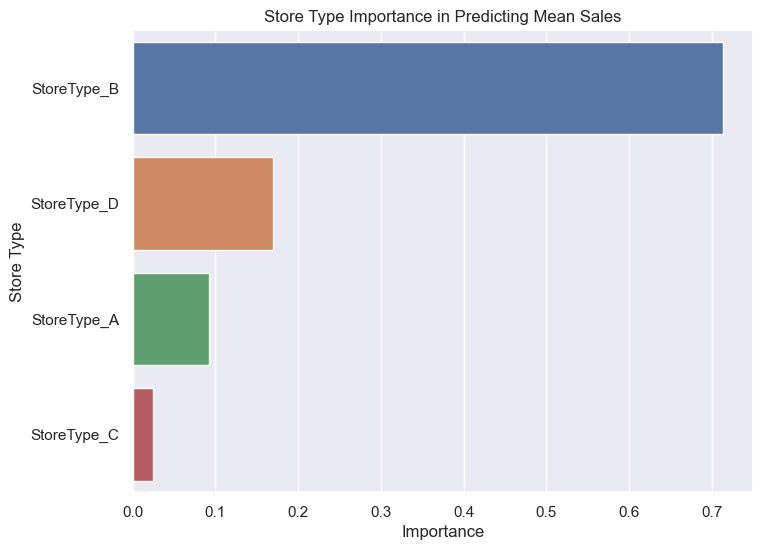

In [95]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


X = df_encoded[['StoreType_A', 'StoreType_B', 'StoreType_C', 'StoreType_D']]  # Include other relevant features
y = df_encoded['Mean_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
features = X.columns
feature_importance = pd.DataFrame({'Store Type': features, 'Importance': importances})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance)

plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Store Type', data=feature_importance)
plt.title('Store Type Importance in Predicting Mean Sales')
plt.show()


Random Forest focuses on how well each feature can reduce the error in predicting the target (cumulative sales) by creating more informative splits at each tree node.

In [96]:
df_encoded1 = pd.get_dummies(merged_df_including_customers, columns=['Assortment'])
df_encoded1.rename(columns = {'Assortment_0': 'Basic', 'Assortment_1': 'Extra', 'Assortment_2': 'Extended'}, inplace = True)
df_encoded1

,Store,Cumulative_Sales,Mean_Sales,StoreType,Promo2,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2SinceWeek,Promo2SinceYear,...,Promo_Jul,Promo_Aug,Promo_Sep,Promo_Oct,Promo_Nov,Promo_Dec,Cluster,Basic,Extra,Extended
0,1,18859.0,9429.500000,2,0,-0.552831,9.000000,2008.000000,23.511971,2011.747698,...,0,0,0,0,0,0,0,True,False,False
1,2,170173.0,9454.055556,0,1,-0.642876,11.000000,2007.000000,13.000000,2010.000000,...,1,0,0,1,0,0,0,True,False,False
2,3,1927200.0,9883.076923,0,1,1.101442,12.000000,2006.000000,14.000000,2011.000000,...,1,0,0,1,0,0,0,True,False,False
3,4,5870093.0,10463.623886,2,0,-0.636445,9.000000,2009.000000,23.511971,2011.747698,...,0,0,0,0,0,0,1,False,False,True
4,5,150450.0,9403.125000,0,0,3.131334,4.000000,2015.000000,23.511971,2011.747698,...,0,0,0,0,0,0,0,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048,1111,375489.0,9387.225000,0,1,-0.471789,6.000000,2014.000000,31.000000,2013.000000,...,1,0,0,1,0,0,0,True,False,False
1049,1112,5973167.0,11851.521825,2,0,-0.474362,4.000000,2006.000000,23.511971,2011.747698,...,0,0,0,0,0,0,1,False,False,True
1050,1113,755444.0,9810.961039,0,0,0.474979,7.204769,2008.681627,23.511971,2011.747698,...,0,0,0,0,0,0,0,False,False,True
1051,1114,16202585.0,20666.562500,0,0,-0.604285,7.204769,2008.681627,23.511971,2011.747698,...,0,0,0,0,0,0,2,False,False,True


  Assortment  Importance
0      Basic    0.595118
2   Extended    0.318110
1      Extra    0.086772


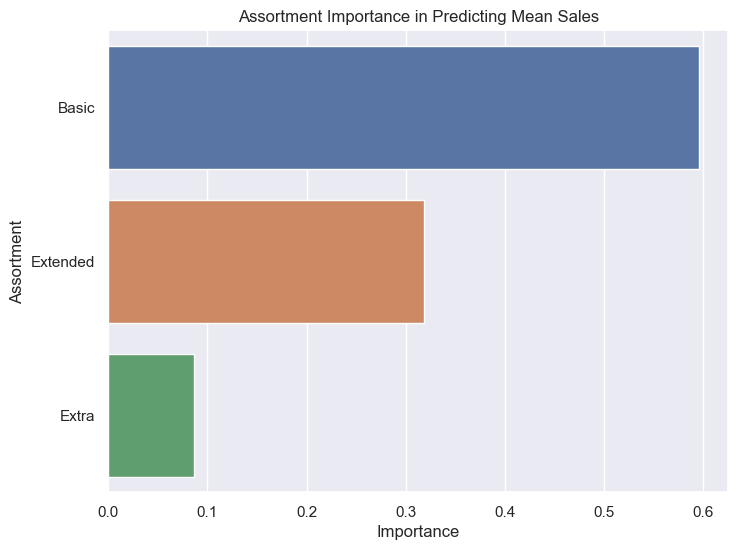

In [97]:

#df_encoded_Assortment = pd.get_dummies(merged_df_including_customers, columns=['Assortment'], drop_first=True)

X = df_encoded1[['Basic','Extra', 'Extended']]  # Include other relevant features
y = df_encoded1['Mean_Sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
features = X.columns
feature_importance = pd.DataFrame({'Assortment': features, 'Importance': importances})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance)

plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Assortment', data=feature_importance)
plt.title('Assortment Importance in Predicting Mean Sales')
plt.show()

In [98]:
df_encoded_fr = pd.get_dummies(merged_df_including_customers, columns=['StoreType', 'Assortment', 'Promo2'])


In [99]:
df_encoded_fr.rename(columns = {'StoreType_0': 'StoreType_A', 'StoreType_1': 'StoreType_B', 'StoreType_2': 'StoreType_C', 'StoreType_3': 'StoreType_D'}, inplace = True)
df_encoded_fr.rename(columns = {'Assortment_0': 'Basic', 'Assortment_1': 'Extra', 'Assortment_2': 'Extended'}, inplace = True)
df_encoded_fr.rename(columns = {'Promo2_0': 'Promo_Off', 'Promo2_1': 'Promo_On'}, inplace = True)
df_encoded_fr[['StoreType','Assortment']] = merged_df_including_customers[['StoreType','Assortment']]
df_encoded_fr

,Store,Cumulative_Sales,Mean_Sales,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2SinceWeek,Promo2SinceYear,Normalised_Sales_cumulative,Normalised_Sales_Mean,...,StoreType_B,StoreType_C,StoreType_D,Basic,Extra,Extended,Promo_Off,Promo_On,StoreType,Assortment
0,1,18859.0,9429.500000,-0.552831,9.000000,2008.000000,23.511971,2011.747698,0.006965,7.172106,...,False,True,False,True,False,False,True,False,2,0
1,2,170173.0,9454.055556,-0.642876,11.000000,2007.000000,13.000000,2010.000000,0.062845,7.190783,...,False,False,False,True,False,False,False,True,0,0
2,3,1927200.0,9883.076923,1.101442,12.000000,2006.000000,14.000000,2011.000000,0.711714,7.517098,...,False,False,False,True,False,False,False,True,0,0
3,4,5870093.0,10463.623886,-0.636445,9.000000,2009.000000,23.511971,2011.747698,2.167822,7.958663,...,False,True,False,False,False,True,True,False,2,2
4,5,150450.0,9403.125000,3.131334,4.000000,2015.000000,23.511971,2011.747698,0.055561,7.152045,...,False,False,False,True,False,False,True,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048,1111,375489.0,9387.225000,-0.471789,6.000000,2014.000000,31.000000,2013.000000,0.138668,7.139951,...,False,False,False,True,False,False,False,True,0,0
1049,1112,5973167.0,11851.521825,-0.474362,4.000000,2006.000000,23.511971,2011.747698,2.205887,9.014303,...,False,True,False,False,False,True,True,False,2,2
1050,1113,755444.0,9810.961039,0.474979,7.204769,2008.681627,23.511971,2011.747698,0.278985,7.462246,...,False,False,False,False,False,True,True,False,0,2
1051,1114,16202585.0,20666.562500,-0.604285,7.204769,2008.681627,23.511971,2011.747698,5.983606,15.719049,...,False,False,False,False,False,True,True,False,0,2


In [100]:
df_encoded_fr.columns

Index(['Store', 'Cumulative_Sales', 'Mean_Sales', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear',
       'Promo2SinceWeek', 'Promo2SinceYear', 'Normalised_Sales_cumulative',
       'Normalised_Sales_Mean', 'Customers', 'Promo_Jan', 'Promo_Feb',
       'Promo_Mar', 'Promo_Apr', 'Promo_May', 'Promo_Jun', 'Promo_Jul',
       'Promo_Aug', 'Promo_Sep', 'Promo_Oct', 'Promo_Nov', 'Promo_Dec',
       'Cluster', 'StoreType_A', 'StoreType_B', 'StoreType_C', 'StoreType_D',
       'Basic', 'Extra', 'Extended', 'Promo_Off', 'Promo_On', 'StoreType',
       'Assortment'],
      dtype='object')

# For PromoInterval  and imputing #

imputer = SimpleImputer(strategy='mean')
df_encoded_fr[['CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear',
            'Promo2SinceWeek', 'Promo2SinceYear']] = imputer.fit_transform(
    df_encoded_fr[['CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear',
                'Promo2SinceWeek', 'Promo2SinceYear']])

scaler = StandardScaler()
merged_df_including_customers[['CompetitionDistance']] = scaler.fit_transform(merged_df_including_customers[['CompetitionDistance']])

The Extra assortment stores likely have more consistent performance with high cumulative sales. The Random Forest model picks up on this consistency and gives it higher importance, even though Basic and Extended assortments have a broader range of sales. 

The random forrest might be influenced by the various number of outliers which may suggest that Extra might be more consistant and producing consistent higher sales than Baic and Extend

In [101]:
#merged_df_including_customers
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df_encoded_fr['High_Sales'] = (df_encoded_fr['Mean_Sales'] > df_encoded_fr['Mean_Sales'].median()).astype(int)

X = df_encoded_fr[['StoreType_A' ,'StoreType_B', 'StoreType_C', 'StoreType_D', 'Basic' ,'Extra', 'Extended', 'Customers','CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 
                'Promo_Off', 'Promo_On', 'Promo2SinceWeek', 'Promo2SinceYear']]  
y = df_encoded_fr['High_Sales']
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X, y, test_size=0.2, random_state=42)
#print(X_test_log)
#print(X_train_log.isna().sum())

model_log = LogisticRegression()
model_log.fit(X_train_log, y_train_log)

y_pred_log = model_log.predict(X_test_log)
#print(y_pred_log)
accuracy = accuracy_score(y_test_log, y_pred_log)
conf_matrix = confusion_matrix(y_test_log, y_pred_log)
class_report = classification_report(y_test_log, y_pred_log)

print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)


Accuracy: 0.7109
Confusion Matrix:
[[81 25]
 [36 69]]
Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.76      0.73       106
           1       0.73      0.66      0.69       105

    accuracy                           0.71       211
   macro avg       0.71      0.71      0.71       211
weighted avg       0.71      0.71      0.71       211



C:\Users\aryak\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [102]:
 df_encoded_fr['Mean_Sales'].median()

9853.729166666666

      StoreType_A  StoreType_B  StoreType_C  StoreType_D  Basic  Extra  \
394         False        False         True        False   True  False   
96          False        False        False         True  False  False   
972         False        False        False         True   True  False   
1052        False        False        False         True  False  False   
59           True        False        False        False   True  False   
...           ...          ...          ...          ...    ...    ...   
429          True        False        False        False  False  False   
988          True        False        False        False   True  False   
552         False        False        False         True  False  False   
342          True        False        False        False  False  False   
796         False        False        False         True   True  False   

      Extended    Customers  CompetitionDistance  CompetitionOpenSinceMonth  \
394      False  1224.000000     

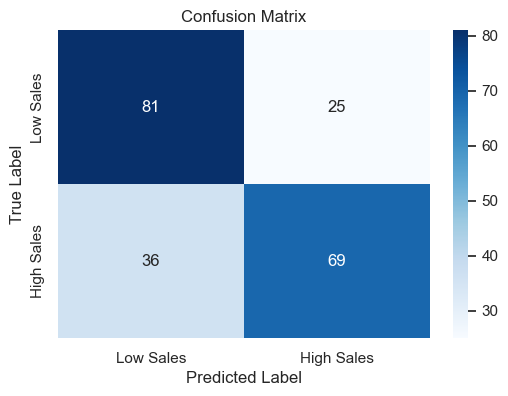

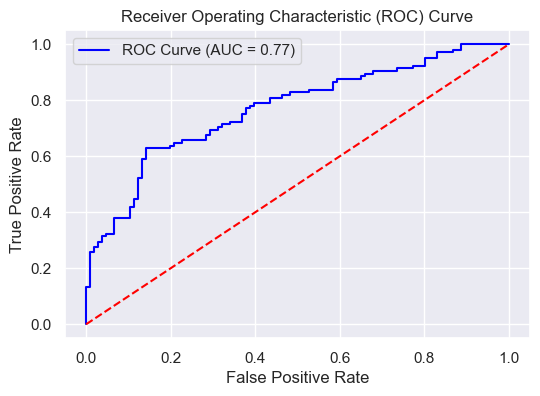

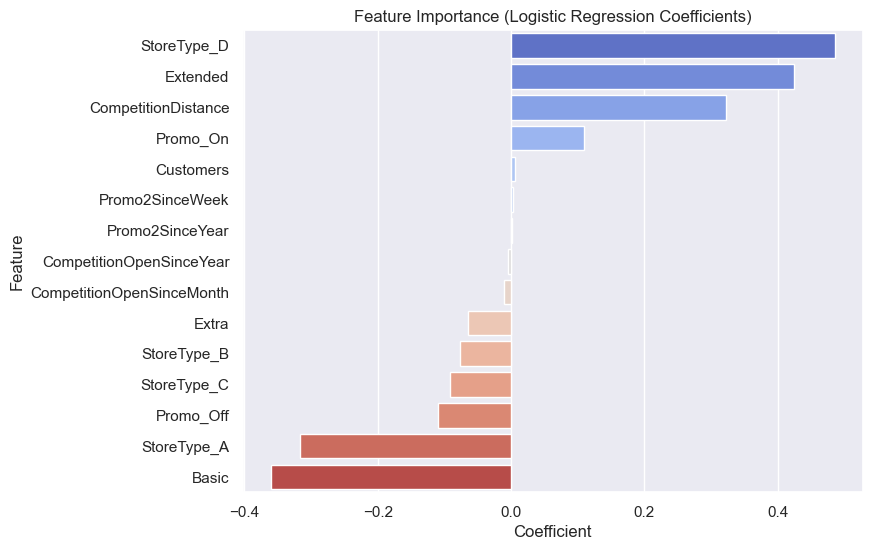

In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

X_test_log = X_test_log.reindex(columns=X_train_log.columns, fill_value=0)
print(X_test_log)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Low Sales', 'High Sales'], yticklabels=['Low Sales', 'High Sales'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

y_pred_prob = model_log.predict_proba(X_test_log)[:, 1]  # Ensure we use the aligned test set
fpr, tpr, thresholds = roc_curve(y_test_log, y_pred_prob)
roc_auc = roc_auc_score(y_test_log, y_pred_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})', color='blue')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Plotting a diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

coef_df = pd.DataFrame({'Feature': X_train_log.columns, 'Coefficient': model_log.coef_[0]})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='coolwarm')
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.show()


In [104]:
threshold = 0.5
y_pred_log_custom = (y_pred_prob > threshold).astype(int)
conf_matrix_custom = confusion_matrix(y_test_log, y_pred_log_custom)
conf_matrix_custom

array([[81, 25],
       [36, 69]], dtype=int64)

In [105]:
df_encoded_fr['High_Sales'].value_counts()


High_Sales
0    527
1    526
Name: count, dtype: int64

In [106]:
df_encoded_fr

,Store,Cumulative_Sales,Mean_Sales,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2SinceWeek,Promo2SinceYear,Normalised_Sales_cumulative,Normalised_Sales_Mean,...,StoreType_C,StoreType_D,Basic,Extra,Extended,Promo_Off,Promo_On,StoreType,Assortment,High_Sales
0,1,18859.0,9429.500000,-0.552831,9.000000,2008.000000,23.511971,2011.747698,0.006965,7.172106,...,True,False,True,False,False,True,False,2,0,0
1,2,170173.0,9454.055556,-0.642876,11.000000,2007.000000,13.000000,2010.000000,0.062845,7.190783,...,False,False,True,False,False,False,True,0,0,0
2,3,1927200.0,9883.076923,1.101442,12.000000,2006.000000,14.000000,2011.000000,0.711714,7.517098,...,False,False,True,False,False,False,True,0,0,1
3,4,5870093.0,10463.623886,-0.636445,9.000000,2009.000000,23.511971,2011.747698,2.167822,7.958663,...,True,False,False,False,True,True,False,2,2,1
4,5,150450.0,9403.125000,3.131334,4.000000,2015.000000,23.511971,2011.747698,0.055561,7.152045,...,False,False,True,False,False,True,False,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048,1111,375489.0,9387.225000,-0.471789,6.000000,2014.000000,31.000000,2013.000000,0.138668,7.139951,...,False,False,True,False,False,False,True,0,0,0
1049,1112,5973167.0,11851.521825,-0.474362,4.000000,2006.000000,23.511971,2011.747698,2.205887,9.014303,...,True,False,False,False,True,True,False,2,2,1
1050,1113,755444.0,9810.961039,0.474979,7.204769,2008.681627,23.511971,2011.747698,0.278985,7.462246,...,False,False,False,False,True,True,False,0,2,0
1051,1114,16202585.0,20666.562500,-0.604285,7.204769,2008.681627,23.511971,2011.747698,5.983606,15.719049,...,False,False,False,False,True,True,False,0,2,1


Accuracy: 0.6967
Confusion Matrix:
[[80 26]
 [38 67]]
Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.75      0.71       106
           1       0.72      0.64      0.68       105

    accuracy                           0.70       211
   macro avg       0.70      0.70      0.70       211
weighted avg       0.70      0.70      0.70       211



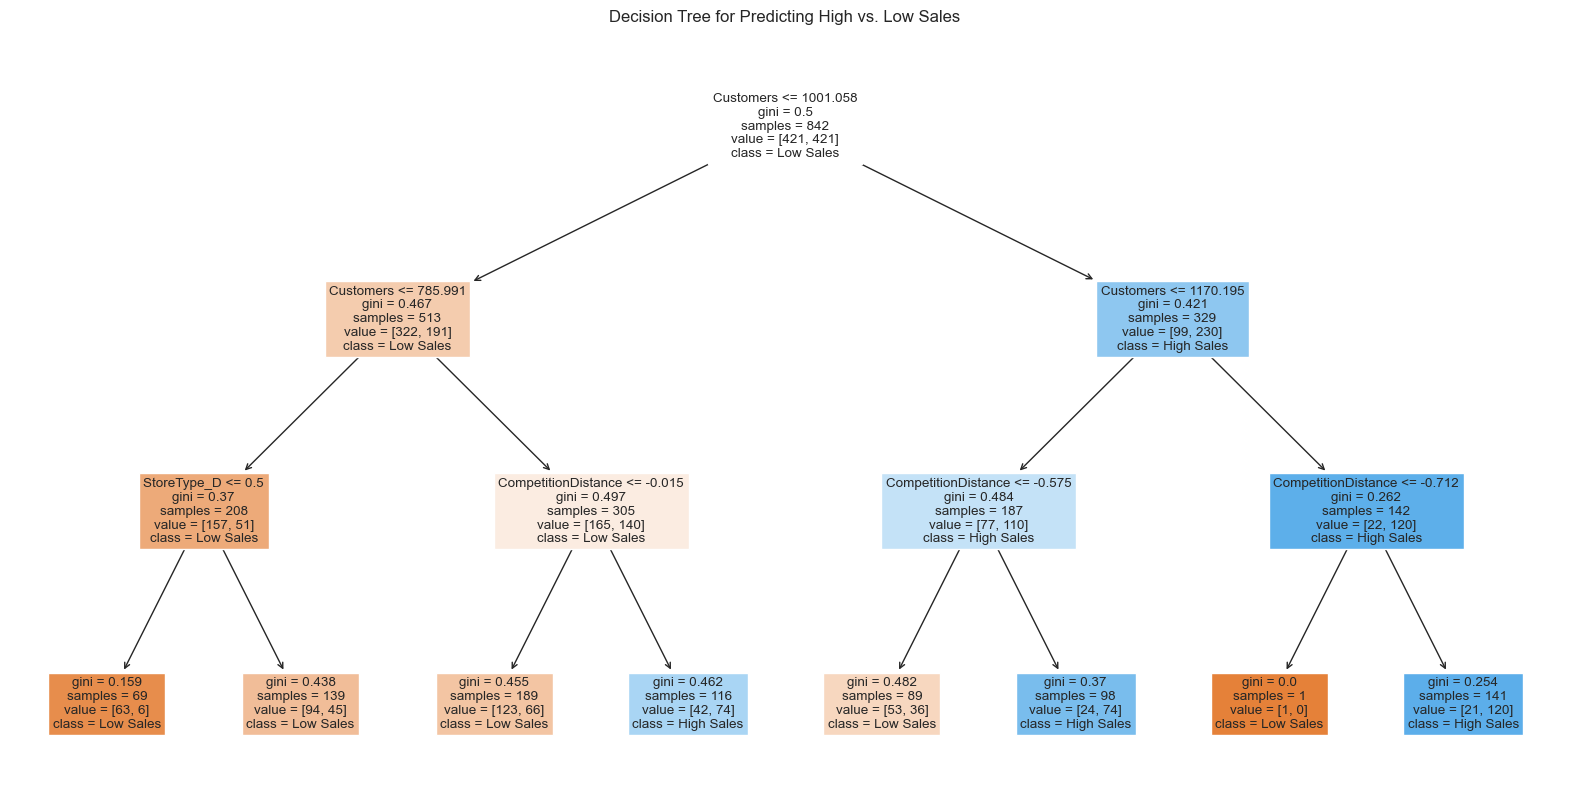

In [107]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import tree
import matplotlib.pyplot as plt

X = df_encoded_fr[['StoreType_A' ,'StoreType_B', 'StoreType_C', 'StoreType_D', 'Basic', 'Extended', 'Customers','CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 
                'Promo_Off', 'Promo_On', 'Promo2SinceWeek', 'Promo2SinceYear']] 

df_encoded_fr['High_Sales'] = (df_encoded_fr['Mean_Sales'] > df_encoded_fr['Mean_Sales'].median()).astype(int)
y = df_encoded_fr['High_Sales']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

decision_tree = DecisionTreeClassifier(random_state=42, max_depth = 3)
decision_tree.fit(X_train, y_train)

y_pred = decision_tree.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

feature_names = X.columns.tolist()
# Step 6: Visualize the Decision Tree
plt.figure(figsize=(20,10))
tree.plot_tree(decision_tree, feature_names=feature_names, class_names=['Low Sales', 'High Sales'], filled=True)
plt.title("Decision Tree for Predicting High vs. Low Sales")
plt.show()


Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Accuracy: 0.5782
Confusion Matrix:
[[68 38]
 [51 54]]
Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.64      0.60       106
           1       0.59      0.51      0.55       105

    accuracy                           0.58       211
   macro avg       0.58      0.58      0.58       211
weighted avg       0.58      0.58      0.58       211



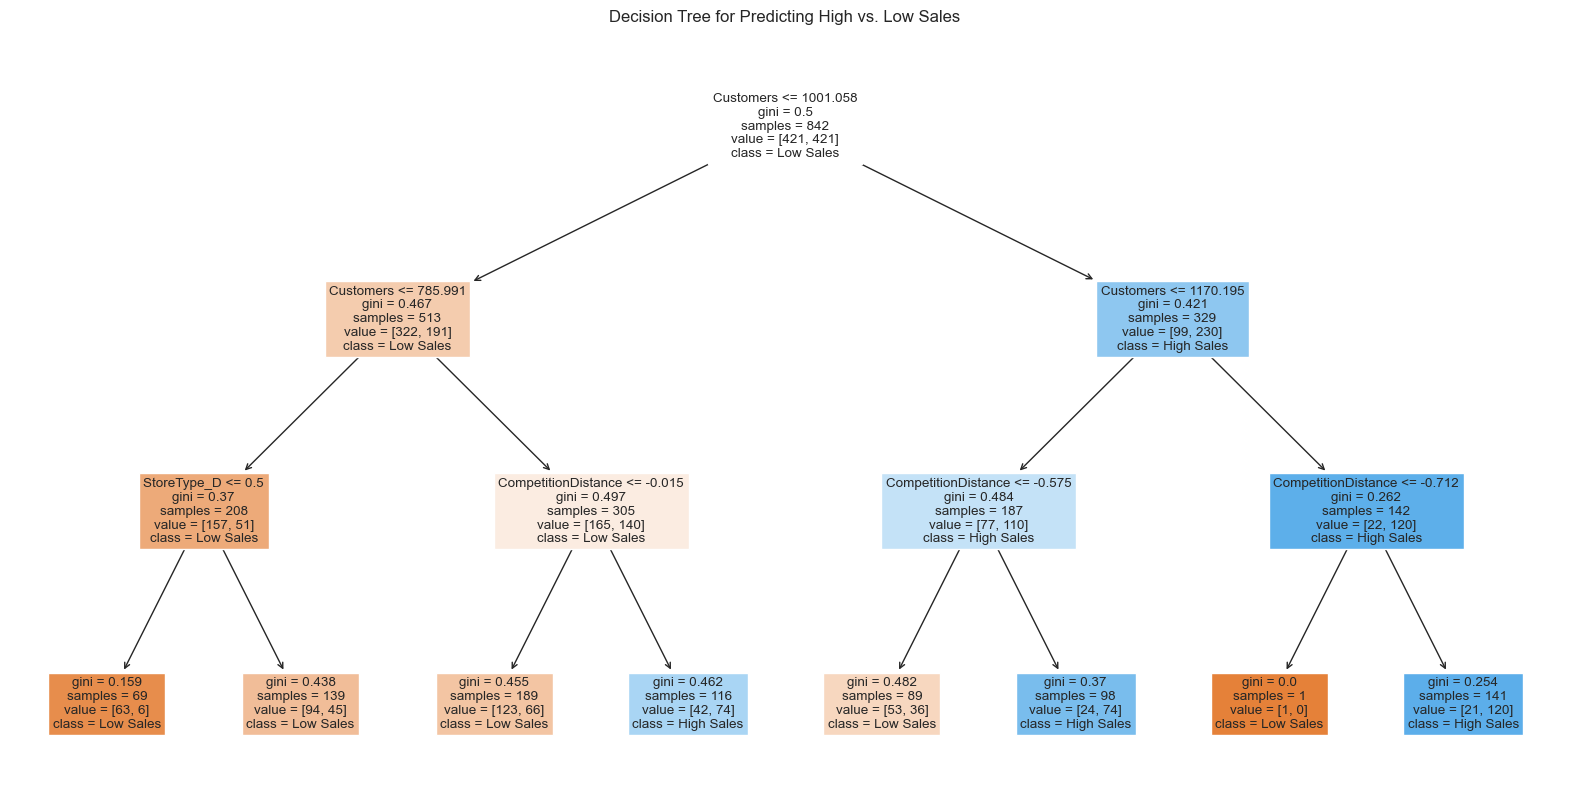

In [108]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import tree
import matplotlib.pyplot as plt

df_encoded_fr['High_Sales'] = (df_encoded_fr['Mean_Sales'] > df_encoded_fr['Mean_Sales'].median()).astype(int)
X1 = df_encoded_fr[['StoreType_A','StoreType_B', 'StoreType_C', 'StoreType_D', 'Basic', 'Extra', 'Extended', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 
                'Promo_Off', 'Promo_On', 'Promo2SinceWeek', 'Promo2SinceYear']]

y = df_encoded_fr['High_Sales']  

X_train, X_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'max_features': [None, 'sqrt', 'log2'],
    'ccp_alpha': [0.0, 0.01, 0.1]  # Cost complexity pruning
}

grid_search = GridSearchCV(estimator=decision_tree, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_tree = grid_search.best_estimator_


y_pred = best_tree.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

feature_names = X.columns.tolist()
# Step 6: Visualize the Decision Tree
plt.figure(figsize=(20,10))
tree.plot_tree(decision_tree, feature_names=feature_names, class_names=['Low Sales', 'High Sales'], filled=True)
plt.title("Decision Tree for Predicting High vs. Low Sales")
plt.show()


Random Forest Accuracy: 0.7393
Confusion Matrix (Random Forest):
[[78 28]
 [27 78]]
Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.74      0.74      0.74       106
           1       0.74      0.74      0.74       105

    accuracy                           0.74       211
   macro avg       0.74      0.74      0.74       211
weighted avg       0.74      0.74      0.74       211



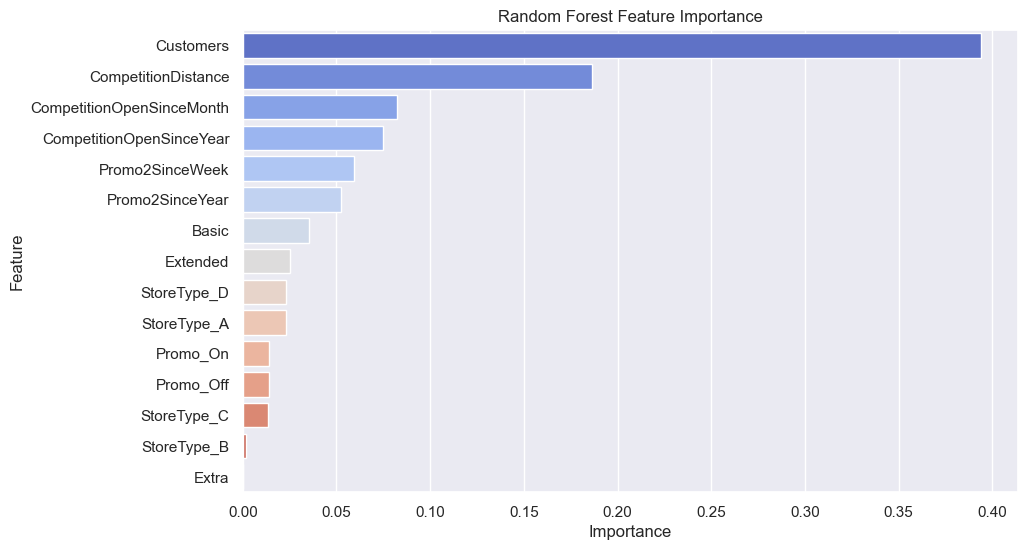

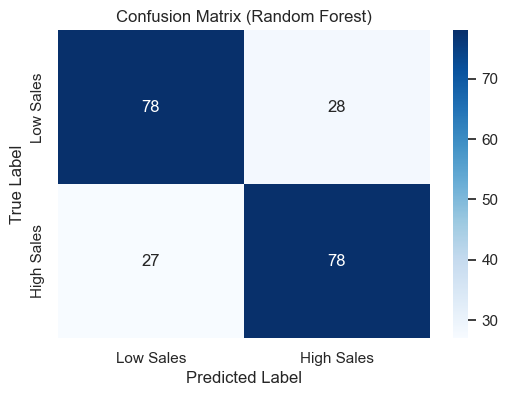

In [109]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


X = df_encoded_fr[['StoreType_A' ,'StoreType_B', 'StoreType_C', 'StoreType_D', 'Basic' ,'Extra', 'Extended', 'Customers','CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 
                'Promo_Off', 'Promo_On', 'Promo2SinceWeek', 'Promo2SinceYear']] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

random_forest = RandomForestClassifier(random_state=42, n_estimators=100,max_depth = 10, min_samples_leaf = 4, min_samples_split = 2)  # n_estimators=100 means 100 decision trees
random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
class_report_rf = classification_report(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print("Confusion Matrix (Random Forest):")
print(conf_matrix_rf)
print("Classification Report (Random Forest):")
print(class_report_rf)

feature_importance_rf = random_forest.feature_importances_
importance_df_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance_rf
})

importance_df_rf = importance_df_rf.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df_rf, palette='coolwarm')
plt.title('Random Forest Feature Importance')
plt.show()

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Low Sales', 'High Sales'], yticklabels=['Low Sales', 'High Sales'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Random Forest)')
plt.show()


# Without Extra #

Random Forest Accuracy: 0.7393
Confusion Matrix (Random Forest):
[[80 26]
 [29 76]]
Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.73      0.75      0.74       106
           1       0.75      0.72      0.73       105

    accuracy                           0.74       211
   macro avg       0.74      0.74      0.74       211
weighted avg       0.74      0.74      0.74       211



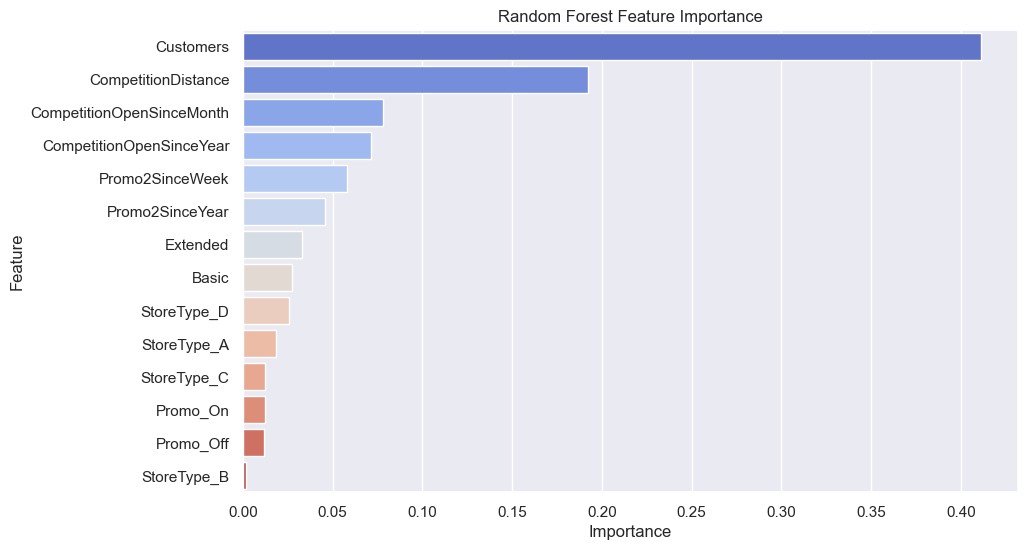

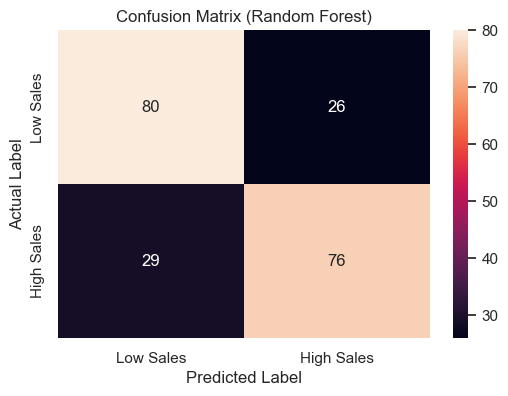

In [110]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


X10 = df_encoded_fr[['StoreType_A' ,'StoreType_B', 'StoreType_C', 'StoreType_D', 'Basic', 'Extended', 'Customers','CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 
                'Promo_Off', 'Promo_On', 'Promo2SinceWeek', 'Promo2SinceYear']] 

X_train, X_test, y_train, y_test = train_test_split(X10, y, test_size=0.2, random_state=42)

random_forest = RandomForestClassifier(random_state=42, n_estimators=100,max_depth = 20, min_samples_leaf = 4, min_samples_split = 10)  # n_estimators=100 means 100 decision trees
random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
class_report_rf = classification_report(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print("Confusion Matrix (Random Forest):")
print(conf_matrix_rf)
print("Classification Report (Random Forest):")
print(class_report_rf)

feature_importance_rf = random_forest.feature_importances_

importance_df_rf = pd.DataFrame({
    'Feature': X10.columns,
    'Importance': feature_importance_rf
})

importance_df_rf = importance_df_rf.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df_rf, palette='coolwarm')
plt.title('Random Forest Feature Importance')
plt.show()

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', xticklabels=['Low Sales', 'High Sales'], yticklabels=['Low Sales', 'High Sales'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix (Random Forest)')
plt.show()


-The model predicts whether the sales where high or low 73.9% of the time correctly
-The model's precision and recall is around 0.7 and thus suggests there is no overfitting or underfitting taking place
-Recall answers the question: "Of all the actual positive instances, how many were correctly identified as positive?"
-"Of all the instances that were predicted as positive (e.g., high sales), how many were actually positive?"
High Precision means that few false positives (wrongly classified positives) are being predicted by the model.
High Recall means that the model is able to detect most of the positive instances, but it might also incorrectly classify some negatives as positives (leading to lower precision).

Random Forest Accuracy: 0.6825
Confusion Matrix (Random Forest):
[[75 31]
 [36 69]]
Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.68      0.71      0.69       106
           1       0.69      0.66      0.67       105

    accuracy                           0.68       211
   macro avg       0.68      0.68      0.68       211
weighted avg       0.68      0.68      0.68       211



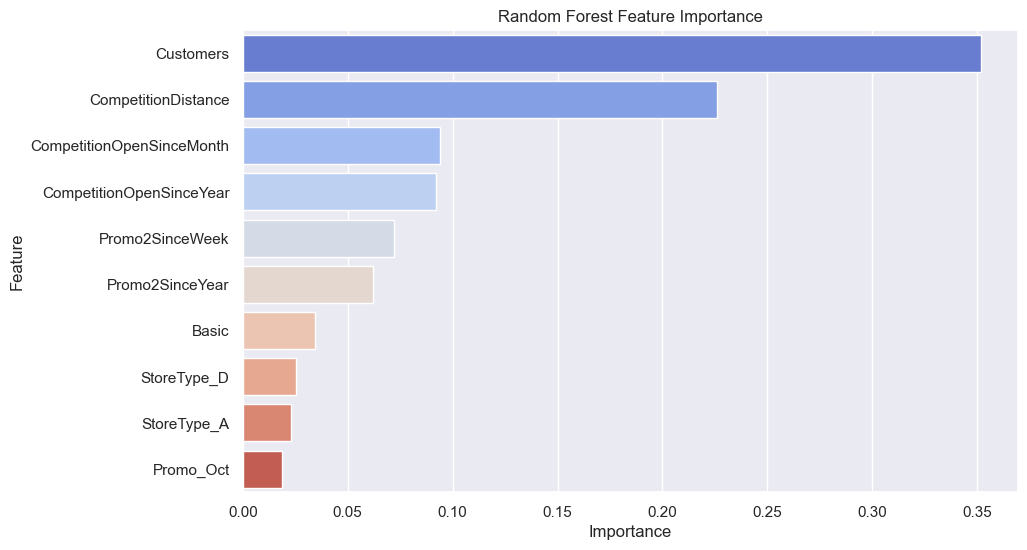

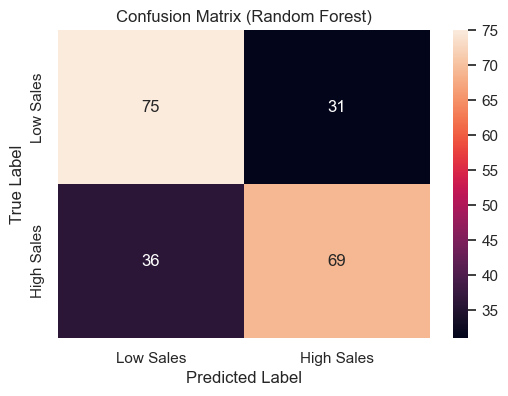

In [111]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


X = df_encoded_fr[['StoreType_A', 'StoreType_D', 'Basic', 'Customers','CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear'
                , 'Promo2SinceWeek', 'Promo2SinceYear', 'Promo_Oct', 
                ]] 


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

random_forest = RandomForestClassifier(random_state=42, n_estimators=100)  # n_estimators=100 means 100 decision trees
random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
class_report_rf = classification_report(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print("Confusion Matrix (Random Forest):")
print(conf_matrix_rf)
print("Classification Report (Random Forest):")
print(class_report_rf)

feature_importance_rf = random_forest.feature_importances_

importance_df_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance_rf
})

importance_df_rf = importance_df_rf.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df_rf, palette='coolwarm')
plt.title('Random Forest Feature Importance')
plt.show()

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', xticklabels=['Low Sales', 'High Sales'], yticklabels=['Low Sales', 'High Sales'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Random Forest)')
plt.show()


In [112]:
from sklearn.feature_selection import RFE

estimator = RandomForestClassifier(n_estimators=100, random_state=42)

selector = RFE(estimator, n_features_to_select=10, step=1)
selector = selector.fit(X_train, y_train)

# Print selected features
print(selector.support_)
print(selector.ranking_)

[ True  True  True  True  True  True  True  True  True  True]
[1 1 1 1 1 1 1 1 1 1]


## Without customers due to its impact ##


Accuracy: 0.5498
Confusion Matrix:
[[49 57]
 [38 67]]
Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.46      0.51       106
           1       0.54      0.64      0.59       105

    accuracy                           0.55       211
   macro avg       0.55      0.55      0.55       211
weighted avg       0.55      0.55      0.55       211



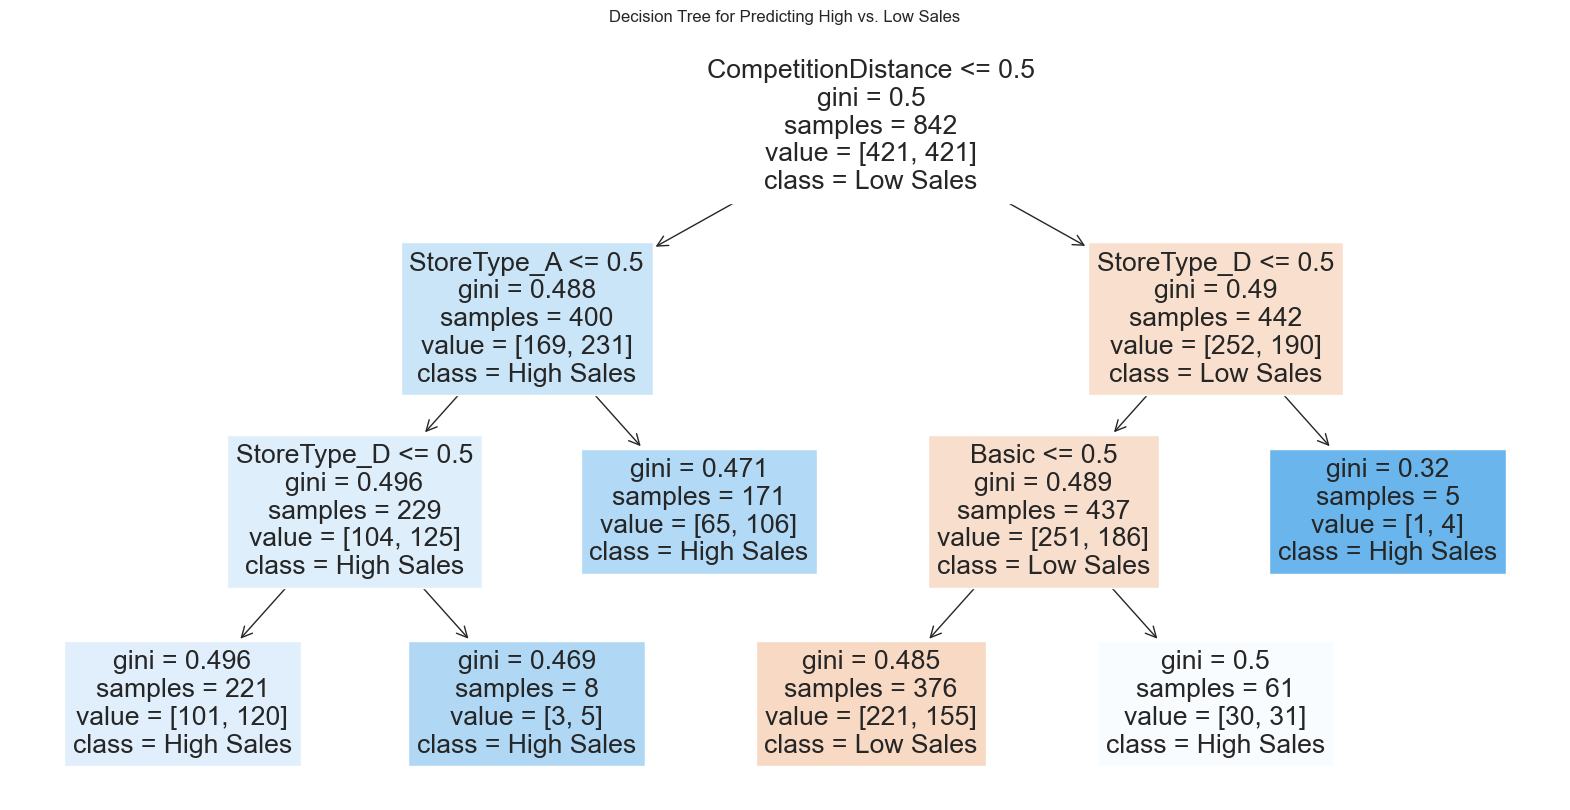

In [113]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import tree
import matplotlib.pyplot as plt


df_encoded_fr['High_Sales'] = (df_encoded_fr['Mean_Sales'] > df_encoded_fr['Mean_Sales'].median()).astype(int)


X2 = df_encoded_fr[['StoreType_A','StoreType_B', 'StoreType_C', 'StoreType_D', 'Basic', 'Extra', 'Extended']]
y = df_encoded_fr['High_Sales']  

X_train, X_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=42)

decision_tree = DecisionTreeClassifier(random_state=42, max_depth = 3)
decision_tree.fit(X_train, y_train)

y_pred = decision_tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

feature_names = X.columns.tolist()
# Step 6: Visualize the Decision Tree
plt.figure(figsize=(20,10))
tree.plot_tree(decision_tree, feature_names=feature_names, class_names=['Low Sales', 'High Sales'], filled=True)
plt.title("Decision Tree for Predicting High vs. Low Sales")
plt.show()


Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Accuracy: 0.5498
Confusion Matrix:
[[49 57]
 [38 67]]
Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.46      0.51       106
           1       0.54      0.64      0.59       105

    accuracy                           0.55       211
   macro avg       0.55      0.55      0.55       211
weighted avg       0.55      0.55      0.55       211



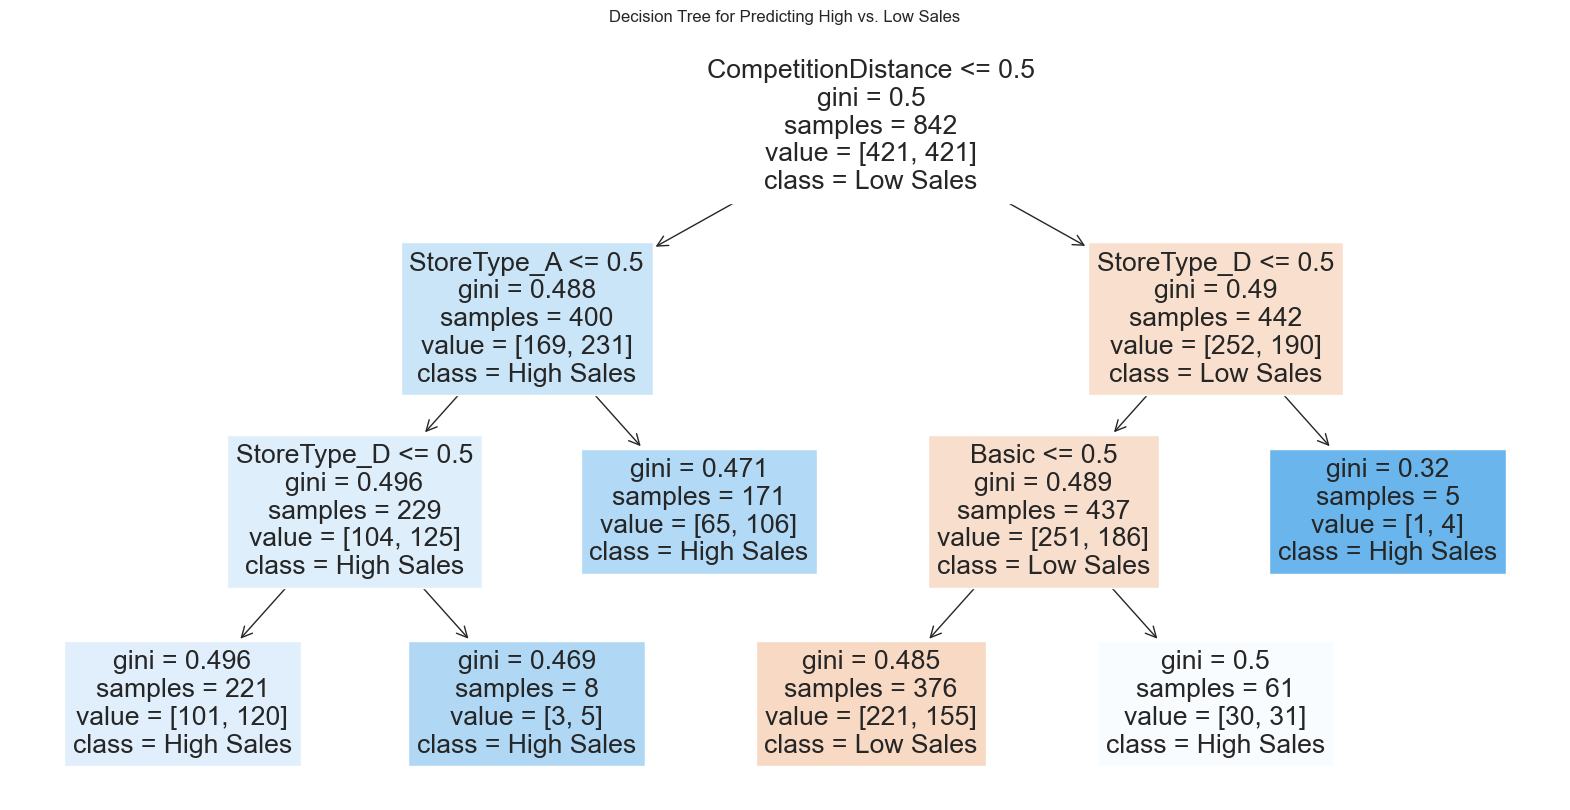

In [114]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import tree
import matplotlib.pyplot as plt


df_encoded_fr['High_Sales'] = (df_encoded_fr['Mean_Sales'] > df_encoded_fr['Mean_Sales'].median()).astype(int)
y = df_encoded_fr['High_Sales']  # Using High_Sales as the binary target
X_train, X_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=42)
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'max_features': [None, 'sqrt', 'log2'],
    'ccp_alpha': [0.0, 0.01, 0.1]  # Cost complexity pruning
}

grid_search = GridSearchCV(estimator=decision_tree, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_tree = grid_search.best_estimator_


y_pred = best_tree.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

feature_names = X.columns.tolist()
# Step 6: Visualize the Decision Tree
plt.figure(figsize=(20,10))
tree.plot_tree(decision_tree, feature_names=feature_names, class_names=['Low Sales', 'High Sales'], filled=True)
plt.title("Decision Tree for Predicting High vs. Low Sales")
plt.show()


Random Forest Accuracy: 0.5782
Confusion Matrix (Random Forest):
[[65 41]
 [48 57]]
Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.58      0.61      0.59       106
           1       0.58      0.54      0.56       105

    accuracy                           0.58       211
   macro avg       0.58      0.58      0.58       211
weighted avg       0.58      0.58      0.58       211



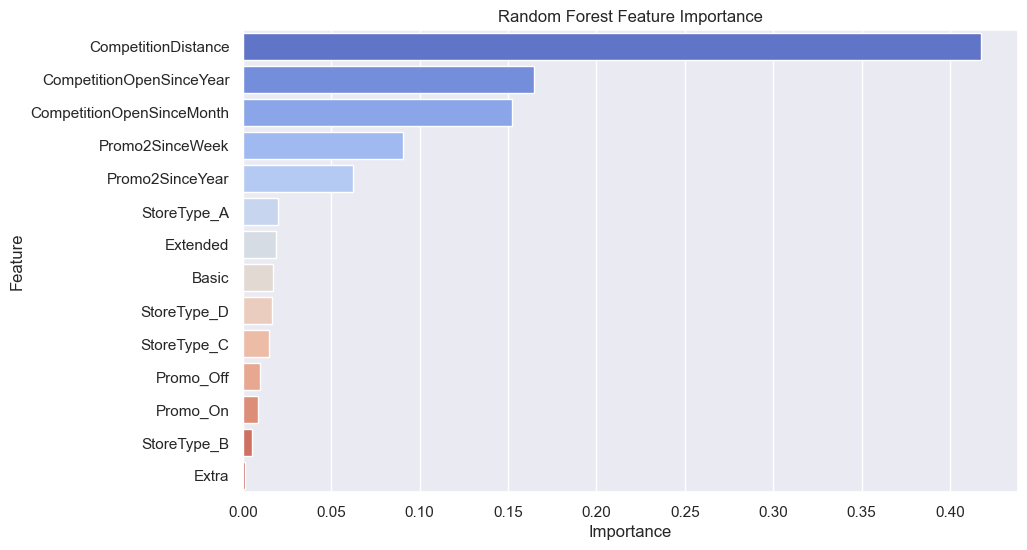

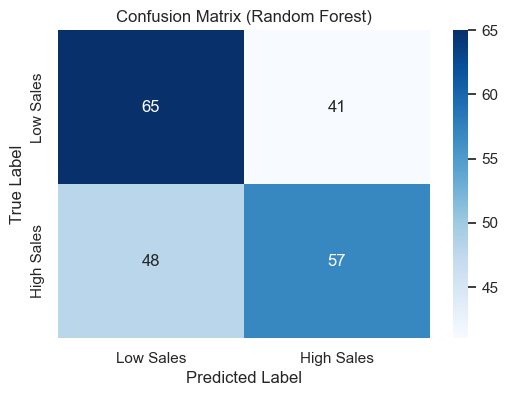

In [115]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns




X_train, X_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)

random_forest = RandomForestClassifier(random_state=42, n_estimators=100)  # n_estimators=100 means 100 decision trees
random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
class_report_rf = classification_report(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print("Confusion Matrix (Random Forest):")
print(conf_matrix_rf)
print("Classification Report (Random Forest):")
print(class_report_rf)

feature_importance_rf = random_forest.feature_importances_

importance_df_rf = pd.DataFrame({
    'Feature': X1.columns,
    'Importance': feature_importance_rf
})

importance_df_rf = importance_df_rf.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df_rf, palette='coolwarm')
plt.title('Random Forest Feature Importance')
plt.show()

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Low Sales', 'High Sales'], yticklabels=['Low Sales', 'High Sales'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Random Forest)')
plt.show()


Random Forest Accuracy: 0.6825
Confusion Matrix (Random Forest):
[[75 31]
 [36 69]]
Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.68      0.71      0.69       106
           1       0.69      0.66      0.67       105

    accuracy                           0.68       211
   macro avg       0.68      0.68      0.68       211
weighted avg       0.68      0.68      0.68       211



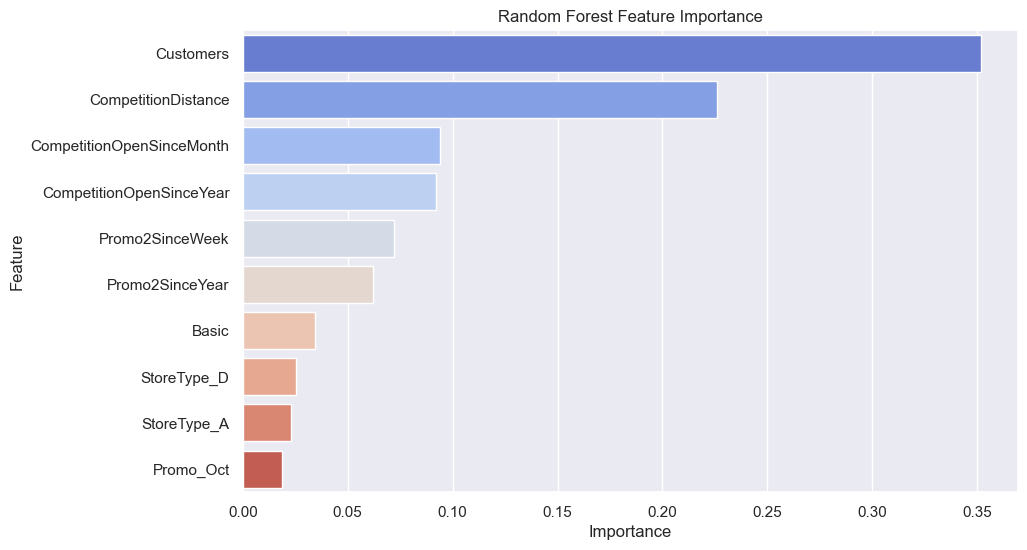

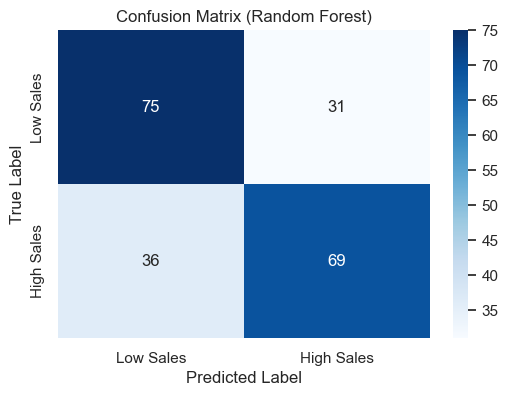

In [116]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
random_forest = RandomForestClassifier(random_state=42, n_estimators=100)  # n_estimators=100 means 100 decision trees
random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
class_report_rf = classification_report(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print("Confusion Matrix (Random Forest):")
print(conf_matrix_rf)
print("Classification Report (Random Forest):")
print(class_report_rf)

feature_importance_rf = random_forest.feature_importances_
importance_df_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance_rf
})

importance_df_rf = importance_df_rf.sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df_rf, palette='coolwarm')
plt.title('Random Forest Feature Importance')
plt.show()

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Low Sales', 'High Sales'], yticklabels=['Low Sales', 'High Sales'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Random Forest)')
plt.show()


# Decision trees with promos #

In [117]:
df_encoded_fr

,Store,Cumulative_Sales,Mean_Sales,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2SinceWeek,Promo2SinceYear,Normalised_Sales_cumulative,Normalised_Sales_Mean,...,StoreType_C,StoreType_D,Basic,Extra,Extended,Promo_Off,Promo_On,StoreType,Assortment,High_Sales
0,1,18859.0,9429.500000,-0.552831,9.000000,2008.000000,23.511971,2011.747698,0.006965,7.172106,...,True,False,True,False,False,True,False,2,0,0
1,2,170173.0,9454.055556,-0.642876,11.000000,2007.000000,13.000000,2010.000000,0.062845,7.190783,...,False,False,True,False,False,False,True,0,0,0
2,3,1927200.0,9883.076923,1.101442,12.000000,2006.000000,14.000000,2011.000000,0.711714,7.517098,...,False,False,True,False,False,False,True,0,0,1
3,4,5870093.0,10463.623886,-0.636445,9.000000,2009.000000,23.511971,2011.747698,2.167822,7.958663,...,True,False,False,False,True,True,False,2,2,1
4,5,150450.0,9403.125000,3.131334,4.000000,2015.000000,23.511971,2011.747698,0.055561,7.152045,...,False,False,True,False,False,True,False,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048,1111,375489.0,9387.225000,-0.471789,6.000000,2014.000000,31.000000,2013.000000,0.138668,7.139951,...,False,False,True,False,False,False,True,0,0,0
1049,1112,5973167.0,11851.521825,-0.474362,4.000000,2006.000000,23.511971,2011.747698,2.205887,9.014303,...,True,False,False,False,True,True,False,2,2,1
1050,1113,755444.0,9810.961039,0.474979,7.204769,2008.681627,23.511971,2011.747698,0.278985,7.462246,...,False,False,False,False,True,True,False,0,2,0
1051,1114,16202585.0,20666.562500,-0.604285,7.204769,2008.681627,23.511971,2011.747698,5.983606,15.719049,...,False,False,False,False,True,True,False,0,2,1


Accuracy: 0.5592
Confusion Matrix:
[[57 49]
 [44 61]]
Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.54      0.55       106
           1       0.55      0.58      0.57       105

    accuracy                           0.56       211
   macro avg       0.56      0.56      0.56       211
weighted avg       0.56      0.56      0.56       211



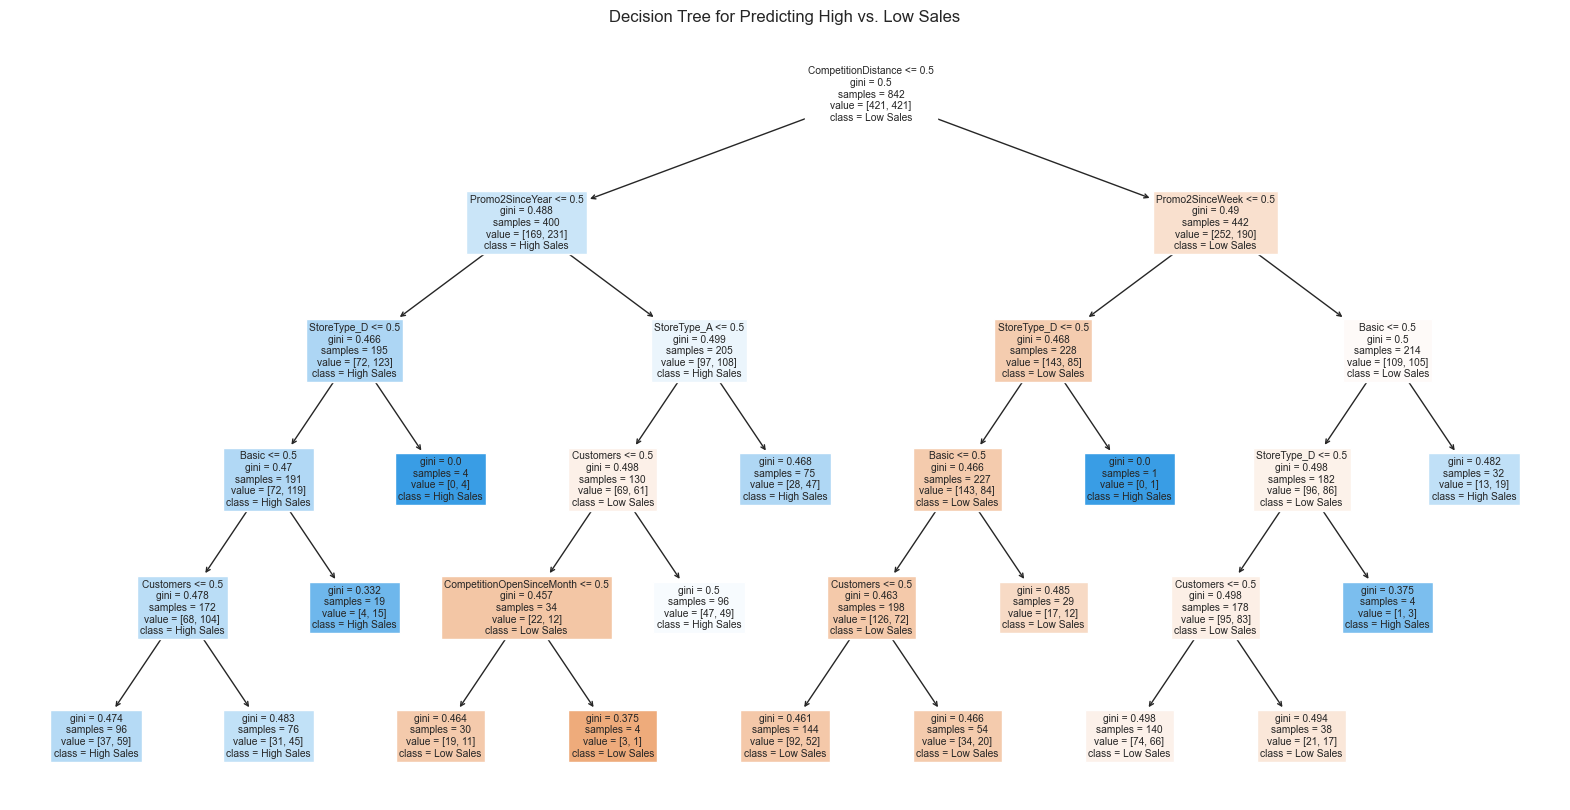

In [118]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import tree
import matplotlib.pyplot as plt

df_encoded_fr['High_Sales'] = (df_encoded_fr['Mean_Sales'] > df_encoded_fr['Mean_Sales'].median()).astype(int)

X4 = df_encoded_fr[['StoreType_A','StoreType_B', 'StoreType_C', 'StoreType_D', 'Basic', 'Extra', 'Extended', 'Promo_Off', 'Promo_On']]
y = df_encoded_fr['High_Sales']  # Using High_Sales as the binary target

X_train, X_test, y_train, y_test = train_test_split(X4, y, test_size=0.2, random_state=42)

decision_tree = DecisionTreeClassifier(random_state=42, max_depth = 5, class_weight = 'balanced')
decision_tree.fit(X_train, y_train)
y_pred = decision_tree.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

feature_names = X.columns.tolist()
plt.figure(figsize=(20,10))
tree.plot_tree(decision_tree, feature_names=feature_names, class_names=['Low Sales', 'High Sales'], filled=True)
plt.title("Decision Tree for Predicting High vs. Low Sales")
plt.show()


Random Forest Accuracy: 0.5782
Confusion Matrix (Random Forest):
[[65 41]
 [48 57]]
Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.58      0.61      0.59       106
           1       0.58      0.54      0.56       105

    accuracy                           0.58       211
   macro avg       0.58      0.58      0.58       211
weighted avg       0.58      0.58      0.58       211



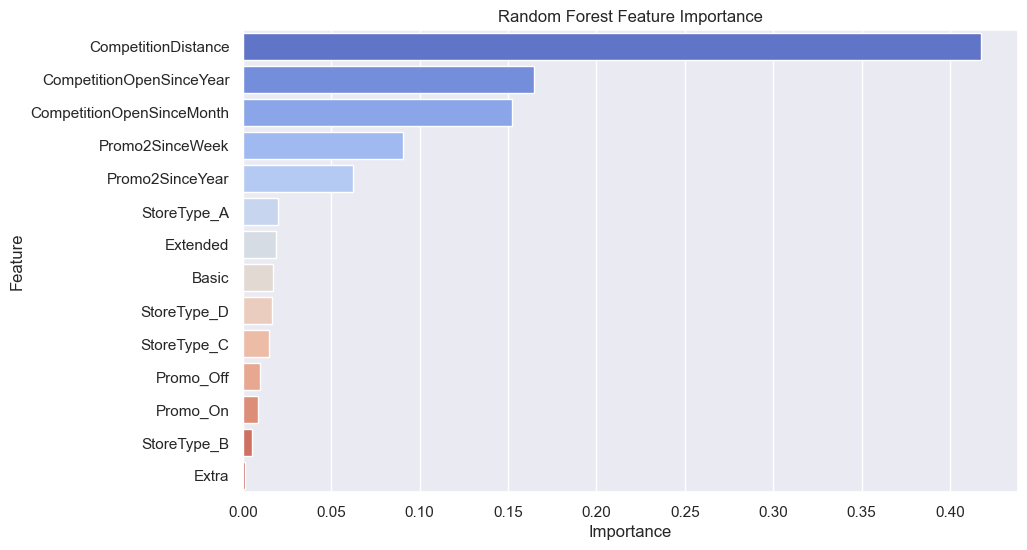

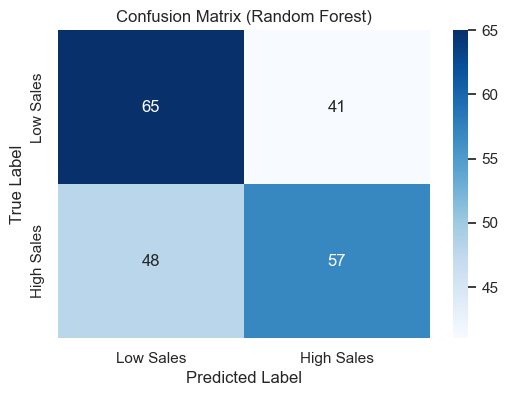

In [119]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns



X1 = df_encoded_fr[['StoreType_A' ,'StoreType_B', 'StoreType_C', 'StoreType_D', 'Basic' ,'Extra', 'Extended','CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 
                'Promo_Off', 'Promo_On', 'Promo2SinceWeek', 'Promo2SinceYear']] 
X_train, X_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)

random_forest = RandomForestClassifier(random_state=42, n_estimators=100, class_weight = 'balanced')  # n_estimators=100 means 100 decision trees
random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
class_report_rf = classification_report(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print("Confusion Matrix (Random Forest):")
print(conf_matrix_rf)
print("Classification Report (Random Forest):")
print(class_report_rf)

feature_importance_rf = random_forest.feature_importances_

importance_df_rf = pd.DataFrame({
    'Feature': X1.columns,
    'Importance': feature_importance_rf
})

importance_df_rf = importance_df_rf.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df_rf, palette='coolwarm')
plt.title('Random Forest Feature Importance')
plt.show()

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Low Sales', 'High Sales'], yticklabels=['Low Sales', 'High Sales'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Random Forest)')
plt.show()


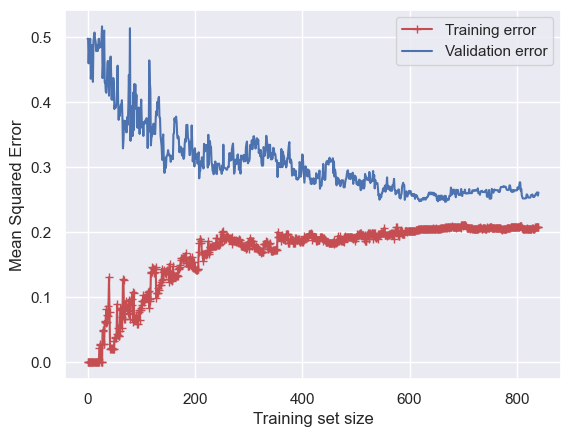

In [120]:
import matplotlib.pyplot as plt

def plot_learning_curves(model, X_train, y_train, X_val, y_val):
    train_errors, val_errors = [], []
    
    for m in range(1, len(X_train)):
        model.fit(X_train[:m], y_train[:m])
        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)
        train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
        val_errors.append(mean_squared_error(y_val, y_val_predict))
    
    plt.plot(train_errors, "r-+", label="Training error")
    plt.plot(val_errors, "b-", label="Validation error")
    plt.legend(loc="best")
    plt.xlabel('Training set size')
    plt.ylabel('Mean Squared Error')
    plt.show()

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

model = DecisionTreeRegressor(max_depth=5)
plot_learning_curves(model, X_train, y_train, X_test, y_test)


SVM Accuracy: 0.7062
Confusion Matrix (SVM):
[[79 27]
 [35 70]]
Classification Report (SVM):
              precision    recall  f1-score   support

           0       0.69      0.75      0.72       106
           1       0.72      0.67      0.69       105

    accuracy                           0.71       211
   macro avg       0.71      0.71      0.71       211
weighted avg       0.71      0.71      0.71       211



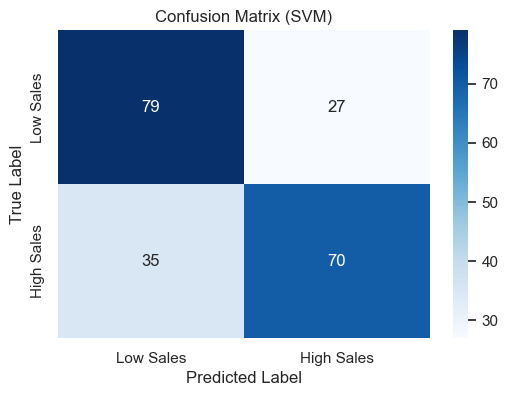

In [121]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # X should be your feature set
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

svm_model = SVC(kernel='rbf', random_state=42)  # Using the default RBF kernel
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
class_report_svm = classification_report(y_test, y_pred_svm)

print(f"SVM Accuracy: {accuracy_svm:.4f}")
print("Confusion Matrix (SVM):")
print(conf_matrix_svm)
print("Classification Report (SVM):")
print(class_report_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low Sales', 'High Sales'], yticklabels=['Low Sales', 'High Sales'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (SVM)')
plt.show()


# Using advanced models #

Accuracy: 0.7299
Confusion Matrix:
[[77 29]
 [28 77]]
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.73      0.73       106
           1       0.73      0.73      0.73       105

    accuracy                           0.73       211
   macro avg       0.73      0.73      0.73       211
weighted avg       0.73      0.73      0.73       211



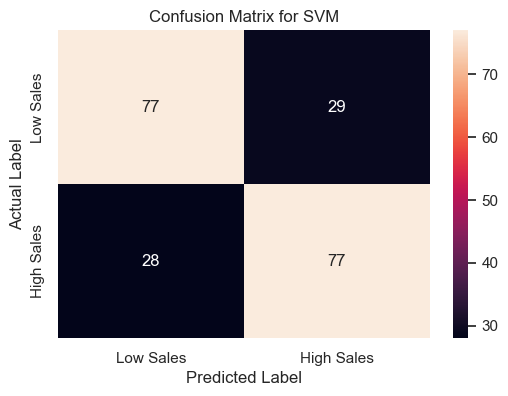

In [122]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X = df_encoded_fr[['StoreType_A', 'StoreType_B', 'StoreType_C', 'StoreType_D', 
                   'CompetitionDistance', 'CompetitionOpenSinceYear', 
                   'Promo2SinceWeek', 'Promo2SinceYear', 'Customers']]
y = df_encoded_fr['High_Sales'] 
X_train, X_test, y_train, y_test = train_test_split(X10, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
svm_clf = SVC(kernel='rbf', random_state=42)
svm_clf.fit(X_train_scaled, y_train)
y_pred = svm_clf.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d',xticklabels=['Low Sales', 'High Sales'], yticklabels=['Low Sales', 'High Sales'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix for SVM')
plt.show()


In [123]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_clf = LogisticRegression()
svc_clf = SVC(probability=True)
tree_clf = DecisionTreeClassifier()
voting_clf = VotingClassifier(estimators=[
    ('logistic', log_clf),
    ('svm', svc_clf),
    ('decision_tree', tree_clf)
], voting='hard') 


voting_clf.fit(X_train, y_train)
voting_clf_soft = VotingClassifier(estimators=[
    ('logistic', log_clf),
    ('svm', svc_clf),
    ('decision_tree', tree_clf)
], voting='soft')

voting_clf_soft.fit(X_train, y_train)
y_pred_soft = voting_clf_soft.predict(X_test)

print(f"Accuracy of Soft Voting Classifier: {accuracy_score(y_test, y_pred_soft):.4f}")
y_pred = voting_clf.predict(X_test)
print(f"Accuracy of Voting Classifier: {accuracy_score(y_test, y_pred):.4f}")



voting_clf_soft = VotingClassifier(estimators=[
    ('logistic', log_clf),
    ('svm', svc_clf),
    ('decision_tree', tree_clf)
], voting='soft')

voting_clf_soft.fit(X_train, y_train)
y_pred_soft = voting_clf_soft.predict(X_test)
print(f"Accuracy of Soft Voting Classifier: {accuracy_score(y_test, y_pred_soft):.4f}")


C:\Users\aryak\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\aryak\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Accuracy of Soft Voting Classifier: 0.6445
Accuracy of Voting Classifier: 0.6967


C:\Users\aryak\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy of Soft Voting Classifier: 0.6493


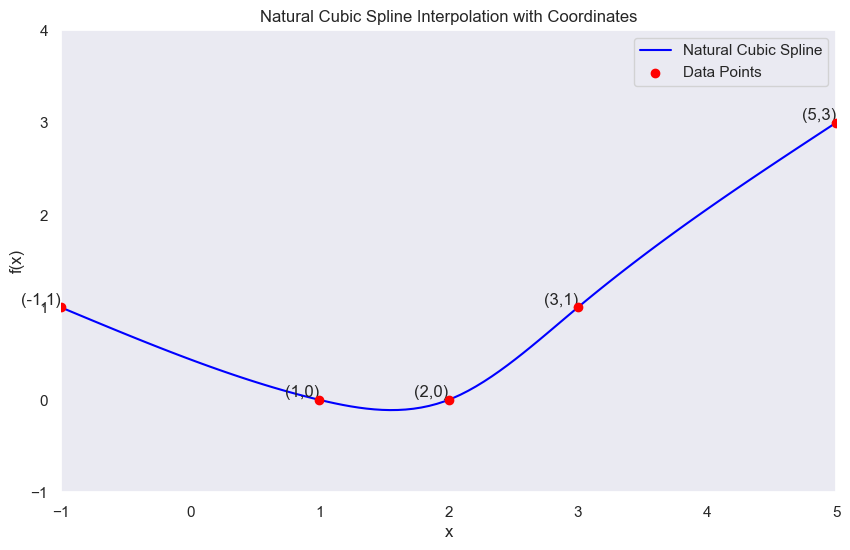

In [124]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
x_points = np.array([-1, 1, 2, 3, 5])
f_points = np.array([1, 0, 0, 1, 3])

cs = CubicSpline(x_points, f_points, bc_type='natural')

x_values = np.linspace(-1, 5, 100)
y_values = cs(x_values)

plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, label='Natural Cubic Spline', color='blue')
plt.scatter(x_points, f_points, color='red', zorder=5, label='Data Points')

for i, (x, y) in enumerate(zip(x_points, f_points)):
    plt.text(x, y, f'({x},{y})', fontsize=12, verticalalignment='bottom', horizontalalignment='right')

plt.title('Natural Cubic Spline Interpolation with Coordinates')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid()
plt.legend()
plt.xlim([-1, 5])
plt.ylim([-1, 4])
plt.show()
